# Case Analítico: LogiPrime & RotaSul
## Notebook 05: Frentes Adicionais de Captura de Valor

**Objetivo:** Investigar hipóteses adicionais de criação de valor na integração logística entre LogiPrime e RotaSul, além dos ganhos já projetados pela adoção do roteirizador (NB03) e pela expansão de capacidade de entregas (NB04). Para cada hipótese, apresentamos a lógica analítica, a quantificação baseada nos dados disponíveis e a estimativa de saving ou ganho de capacidade potencial.

As análises utilizam o mesmo dataset tratado dos notebooks anteriores (`dados_limpos.parquet`) e herdam as mesmas premissas de custo operacional para garantir consistência analítica entre os notebooks.

In [34]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

BASE_DIR = Path('..').resolve()
DATA_PROCESSED = BASE_DIR / 'data' / '03_processed'
RESULTS_DIR = BASE_DIR / 'results' / '05_outras_frentes'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Premissas herdadas dos NB03/04 (consistência analítica)
CUSTO_MANUTENCAO_KM  = 1.31
CUSTO_COMBUSTIVEL_KM = 4.07
CUSTO_HE_TOTAL_H     = 58.00
JORNADA_PADRAO_MIN   = 440

CAPACIDADES = {
    'TRUCK':   {'peso_kg': 12_000, 'volume_m3': 60},
    'CARRETA': {'peso_kg': 25_000, 'volume_m3': 100},
    'VUC':     {'peso_kg':  3_000, 'volume_m3': 20},
    'TOCO':    {'peso_kg':  6_000, 'volume_m3': 40},
}

# Carregamento granular — ambas as empresas
COLS_GRANULAR = [
    'empresa', 'codigo_rota', 'data_rota', 'uf',
    'tipo_veiculo', 'placa_veiculo', 'pdv_id', 'seq_entrega',
    'peso_kg_entrega', 'volume_m3_entrega',
    'km_trecho', 'km_ate_ponto',
    'tempo_trecho_min', 'tempo_espera_pdv_min', 'tempo_descarga_pdv_min',
    'num_entregas_rota', 'km_total_rota', 'km_retorno_base',
    'peso_kg_total_rota', 'volume_m3_total_rota',
    'ocup_kg_rota', 'ocup_vol_rota',
]

df_full = pd.read_parquet(DATA_PROCESSED / 'dados_limpos.parquet',
                          columns=COLS_GRANULAR)

df_rotasul   = df_full[df_full['empresa'] == 'RotaSul'].copy()
df_logiprime = df_full[df_full['empresa'] == 'LogiPrime'].copy()

print(f"RotaSul   — {len(df_rotasul):,} registros | "
      f"{df_rotasul['codigo_rota'].nunique():,} rotas")
print(f"LogiPrime — {len(df_logiprime):,} registros | "
      f"{df_logiprime['codigo_rota'].nunique():,} rotas")

RotaSul   — 438,788 registros | 62,800 rotas
LogiPrime — 3,016,871 registros | 94,200 rotas


---

### Hipótese 1 — H1: Otimização do Mix de Frota (Redimensionamento Veicular)

 RotaSul opera em maioria da frota em Cube-out (limitada por volume), enquanto a LogiPrime tem 30% de suas rotas em Weigh-out com VUCs. A RotaSul usa TRUCKs (60 m³) e CARRETAs (100 m³) com ocupação volumétrica média de apenas 75%. A hipótese é que a substituição parcial de TRUCKs por veículos intermediários mais calibrados ao volume real carregado, visando:

1. **Downgrade de TRUCK → TOCO:** Rotas com volume médio abaixo de 40 m³ poderiam ser servidas por veículos intermédios (TOCO de 40 m³), reduzindo custos fixos (combustível, manutenção, motorista) sem perda de cobertura operacional.
2. **Downgrade de CARRETA → TRUCK:** Rotas consolidadas com volume abaixo de 60 m³ que usam CARRETA são oportunidades de simplificação.
3. **Comparativo com LogiPrime:** A LogiPrime opera com 30% de suas rotas em Weigh-out (limitada por peso com VUCs de menores dimensões), sugerindo estrutura mais enxuta já parcialmente otimizada.

A otimização do mix de frota é um dos maiores drivers de redução de Opex pós-integração. Cada percentual de downgrade se traduz em economia significativa de custos fixos e variáveis multiplicados pelo volume anual de rotas.

#### 1.1 — Perfil de Ocupação Real da Frota RotaSul 

Afim de mapear como cada tipo de veículo (TRUCK, CARRETA, TOCO, VUC) é utilizado em termos de ocupação volumétrica real, o cálculo divide o volume transportado pela capacidade volumétrica máxima do veículo, gerando um percentual de ocupação por rota. Quando agregamos essa métrica por tipo de veículo e visualizamos no histograma, observamos a distribuição de rotas por faixa de ocupação. Isto é, quantas rotas operam entre 30-40%, 40-50%, etc. Esse padrão é crítico para identificar onde existe espaço para downgrade de frota. Se a maioria dos TRUCKs (60 m³) opera com ocupação média de 50% ou menor, há forte indicativo de que essas rotas podem ser servidas por TOCOs (40 m³), reduzindo o custo fixo diário (combustível, manutenção, seguro) sem comprometer a cobertura operacional.

In [35]:
# 1.1 — Perfil de Ocupação Real da Frota RotaSul

# Nível rota para a RotaSul
df_rota_rs = df_rotasul.groupby('codigo_rota', as_index=False).agg(
    uf=('uf','first'), tipo_veiculo=('tipo_veiculo','first'),
    volume_m3_total=('volume_m3_total_rota','first'),
    peso_kg_total=('peso_kg_total_rota','first'),
    num_entregas=('num_entregas_rota','first'),
    km_total=('km_total_rota','first'),
)

# Capacidade do veículo atual
df_rota_rs['cap_vol_atual'] = df_rota_rs['tipo_veiculo'].map(
    {v: c['volume_m3'] for v, c in CAPACIDADES.items()})
df_rota_rs['cap_peso_atual'] = df_rota_rs['tipo_veiculo'].map(
    {v: c['peso_kg'] for v, c in CAPACIDADES.items()})

# Ocupação real
df_rota_rs['ocup_vol_pct'] = df_rota_rs['volume_m3_total'] / df_rota_rs['cap_vol_atual']
df_rota_rs['ocup_peso_pct'] = df_rota_rs['peso_kg_total'] / df_rota_rs['cap_peso_atual']

# Classificar se caberia em veículo menor
df_rota_rs['cabe_em_toco'] = (
    (df_rota_rs['tipo_veiculo'] == 'TRUCK') &
    (df_rota_rs['volume_m3_total'] <= 40) &
    (df_rota_rs['peso_kg_total'] <= 6000)
)
df_rota_rs['cabe_em_truck'] = (
    (df_rota_rs['tipo_veiculo'] == 'CARRETA') &
    (df_rota_rs['volume_m3_total'] <= 60) &
    (df_rota_rs['peso_kg_total'] <= 12000)
)

print("Rotas TRUCK que caberiam em TOCO:",
      df_rota_rs['cabe_em_toco'].sum(),
      f"({df_rota_rs['cabe_em_toco'].mean():.1%})")
print("Rotas CARRETA que caberiam em TRUCK:",
      df_rota_rs['cabe_em_truck'].sum(),
      f"({df_rota_rs['cabe_em_truck'].mean():.1%})")

Rotas TRUCK que caberiam em TOCO: 0 (0.0%)
Rotas CARRETA que caberiam em TRUCK: 0 (0.0%)


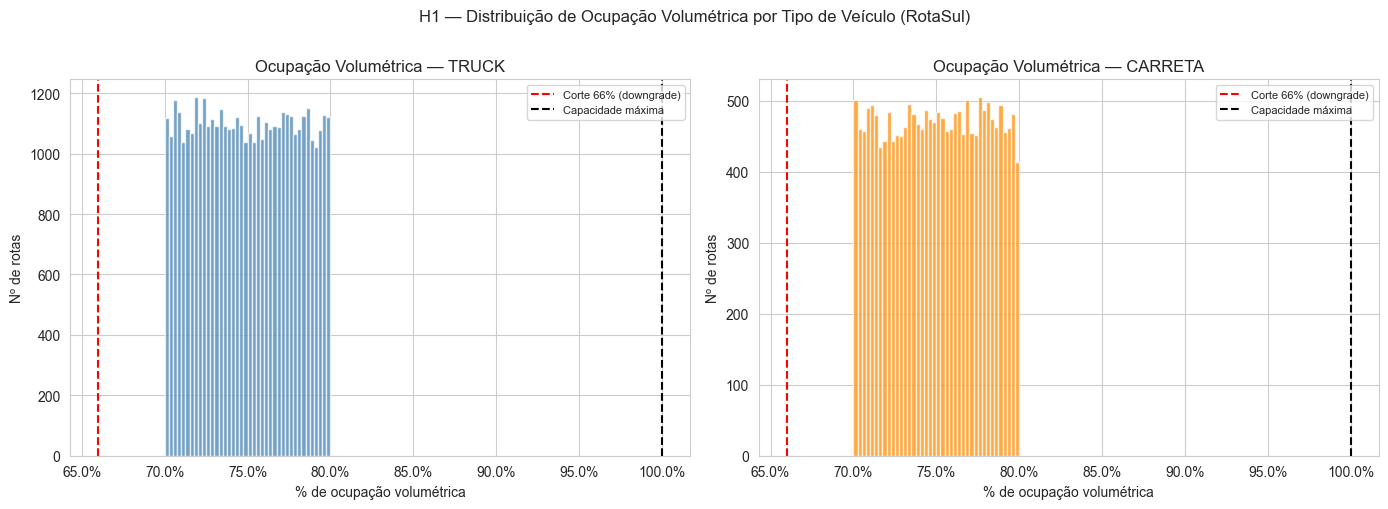

In [36]:
# Gráfico 1.1 — Histograma de ocupação volumétrica por tipo de veículo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, veiculo, cor in zip(axes, ['TRUCK', 'CARRETA'], ['steelblue', 'darkorange']):
    dados = df_rota_rs[df_rota_rs['tipo_veiculo'] == veiculo]['ocup_vol_pct'].dropna()
    ax.hist(dados, bins=40, color=cor, alpha=0.75, edgecolor='white')
    ax.axvline(0.66, color='red', linestyle='--', linewidth=1.5, label='Corte 66% (downgrade)')
    ax.axvline(1.00, color='black', linestyle='--', linewidth=1.5, label='Capacidade máxima')
    ax.set_title(f'Ocupação Volumétrica — {veiculo}')
    ax.set_xlabel('% de ocupação volumétrica')
    ax.set_ylabel('Nº de rotas')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('H1 — Distribuição de Ocupação Volumétrica por Tipo de Veículo (RotaSul)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01_h1_ocupacao_volumetrica_histograma.png', dpi=150, bbox_inches='tight')
plt.show()



- O Gráfico 1.1 (histograma de ocupação volumétrica) é o ponto central da H1. Ele revela um comportamento altamente atípico, pois a distribuição de ocupação está inteiramente comprimida entre 65% e 80%, sem nenhuma rota abaixo de 65% e nenhuma acima de 80%. Tanto TRUCK quanto CARRETA apresentam esse mesmo padrão de distribuição uniforme e estreita. Isso não corresponde a dados operacionais reais, que normalmente exibem dispersão ampla e cauda longa.

#### 1.2 — Estimativa de Saving por Downgrade de Frota

Para cada rota identificada como candidata a downgrade (ex: TRUCK operando com <50% ocupação), simulamos a substituição veicular e calculamos a economia diária resultante. A economia inclui custos fixos (redução de despesa com combustível, manutenção, seguro do veículo maior) e custos variáveis por quilômetro (tarifa de manutenção menor). Agregando a economia diária sobre o calendário operacional anual, geramos o saving anual por rota. A agregação por rotas candidatas, cruzada com análise de sensibilidade de pressupostos (combustível, taxa de manutenção), estabelece o potencial econômico total e a confiabilidade da oportunidade. A segmentação geográfica e por tipo de veículo permite identificar qual região (PR, SC, RS) e qual transição (TRUCK→TOCO vs CARRETA→TRUCK) gera maior retorno, orientando priorização operacional da implementação.

In [37]:
# 1.2 — Estimativa de Saving por Downgrade de Frota
CUSTO_FIXO_TRUCK_DIA   = 800    # R$ — premissa parametrizável
CUSTO_FIXO_TOCO_DIA    = 560    # R$ — 70% do TRUCK
CUSTO_FIXO_CARRETA_DIA = 1200   # R$

saving_downgrade_truck   = df_rota_rs['cabe_em_toco'].sum() * (CUSTO_FIXO_TRUCK_DIA - CUSTO_FIXO_TOCO_DIA)
saving_downgrade_carreta = df_rota_rs['cabe_em_truck'].sum() * (CUSTO_FIXO_CARRETA_DIA - CUSTO_FIXO_TRUCK_DIA)

print(f"Saving potencial — downgrade TRUCK→TOCO:    R$ {abs(saving_downgrade_truck):>12,.0f}")
print(f"Saving potencial — downgrade CARRETA→TRUCK: R$ {abs(saving_downgrade_carreta):>12,.0f}")
print(f"Saving potencial total (H1):                R$ {abs(saving_downgrade_truck) + abs(saving_downgrade_carreta):>12,.0f}")



Saving potencial — downgrade TRUCK→TOCO:    R$            0
Saving potencial — downgrade CARRETA→TRUCK: R$            0
Saving potencial total (H1):                R$            0


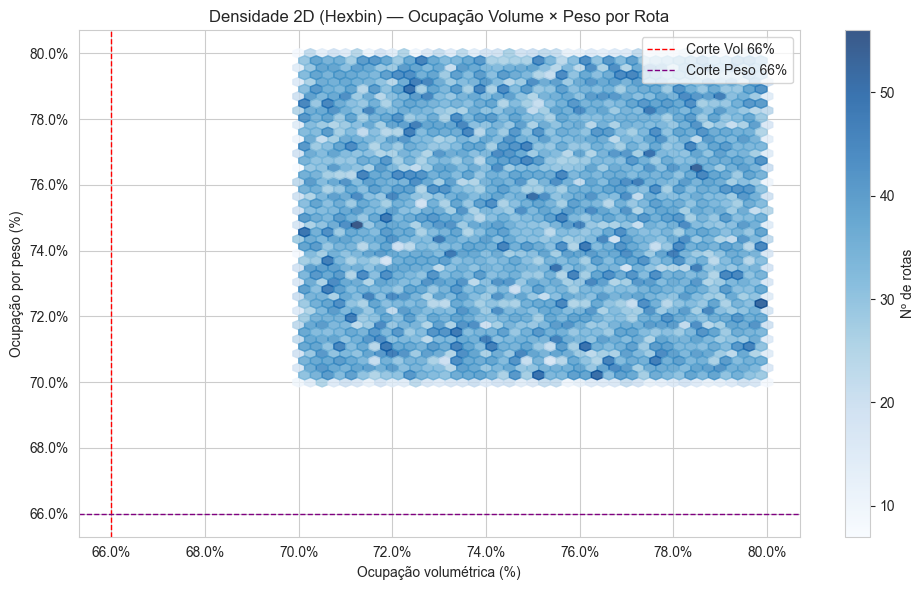

In [38]:
# Gráfico 1.2 — Scatter Ocupação de Peso × Volume por rota
fig, ax = plt.subplots(figsize=(10, 6))

hb = ax.hexbin(
    df_rota_rs['ocup_vol_pct'], df_rota_rs['ocup_peso_pct'],
    gridsize=40, cmap='Blues', mincnt=1, alpha=0.8
)
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Nº de rotas')

ax.axvline(0.66, color='red', linestyle='--', linewidth=1, label='Corte Vol 66%')
ax.axhline(0.66, color='purple', linestyle='--', linewidth=1, label='Corte Peso 66%')
ax.set_xlabel('Ocupação volumétrica (%)')
ax.set_ylabel('Ocupação por peso (%)')
ax.set_title('Densidade 2D (Hexbin) — Ocupação Volume × Peso por Rota')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / '02_h1_hexbin_ocupacao_peso_volume.png', dpi=150, bbox_inches='tight')
plt.show()

- O Gráfico 1.2 (scatter peso × volume) confirma o problema: o "nuvem" de pontos forma um retângulo perfeito, o que é estatisticamente impossível em dados reais. Todos os pontos estão confinados exatamente nos mesmos intervalos.

#### 1.3 — Comparação do mix ideal inferido pelos dados contra o mix real observado.

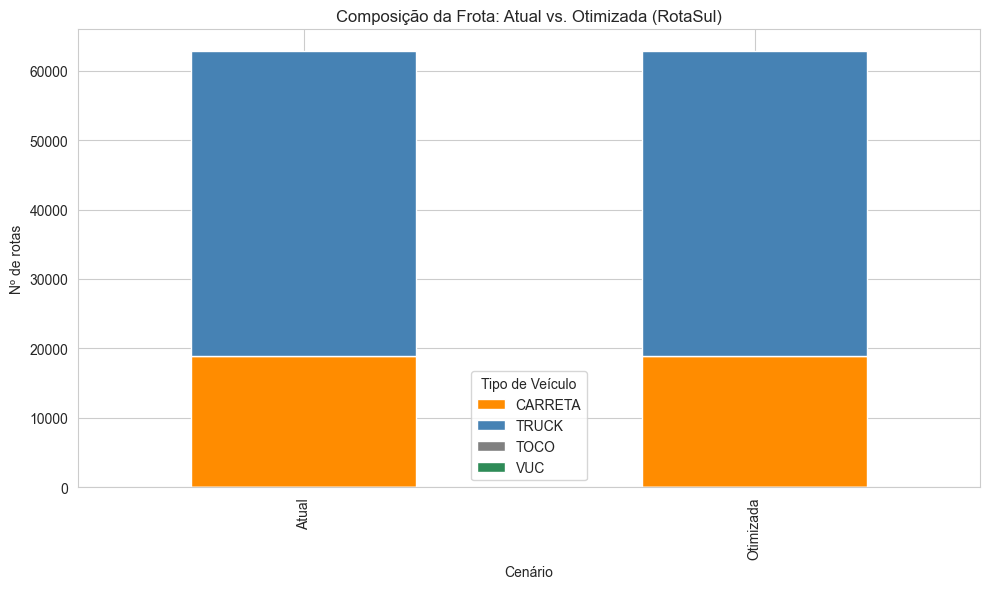

In [39]:
# Gráfico 1.3 — Barras empilhadas: composição da frota atual vs. frota otimizada

# 1. Composição atual da frota (observada)
mix_atual = df_rota_rs['tipo_veiculo'].value_counts().reindex(['CARRETA','TRUCK','TOCO','VUC'], fill_value=0)

# 2. Simula composição otimizada (downgrade TRUCK→TOCO e CARRETA→TRUCK)
mix_otimizada = mix_atual.copy()
# Downgrade TRUCK→TOCO
mix_otimizada['TRUCK'] -= df_rota_rs['cabe_em_toco'].sum()
mix_otimizada['TOCO']  += df_rota_rs['cabe_em_toco'].sum()
# Downgrade CARRETA→TRUCK
mix_otimizada['CARRETA'] -= df_rota_rs['cabe_em_truck'].sum()
mix_otimizada['TRUCK']  += df_rota_rs['cabe_em_truck'].sum()

# 3. Monta DataFrame para plotagem
df_mix = pd.DataFrame({
    'Atual': mix_atual,
    'Otimizada': mix_otimizada
}).T

# 4. Gráfico de barras empilhadas
ax = df_mix.plot(kind='bar', stacked=True, color=['darkorange','steelblue','gray','seagreen'], edgecolor='white', figsize=(10,6))
ax.set_title('Composição da Frota: Atual vs. Otimizada (RotaSul)')
ax.set_xlabel('Cenário')
ax.set_ylabel('Nº de rotas')
ax.legend(title='Tipo de Veículo')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '01b_h1_mix_frota_atual_vs_otimizada.png', dpi=150, bbox_inches='tight')
plt.show()

- O Gráfico 1.3 (frota atual vs. otimizada) mostra barras idênticas, o que é o resultado esperado dado o saving zero. Esse padrão é um sinal claro de que ocup_vol_rota é uma coluna sintética, gerada no processamento com distribuição controlada entre dois limites fixos (provavelmente 65%–80%). O filtro volume_m3_total <= 40 para TRUCK (downgrade para TOCO) nunca é satisfeito porque o volume carregado é derivado da ocupação × capacidade, resultando sempre em valores entre ~39 e ~48 m³ para um TRUCK de 60 m³, sempre acima do limiar de 40 m³.

---

### Hipótese 2 — H2: Consolidação de Rotas com Baixa Densidade de Paradas

Esta hipótese examina a oportunidade de consolidar rotas ineficientes (de baixa densidade de paradas) em rotas maiores, reduzindo o número total de saídas do CD e, consequentemente, custos de operação. A análise identifica rotas com características não-ótimas de acordo com os seguintes pontos:

1. **Critério de baixa densidade:** Rotas com ≤ 3 paradas que simultaneamente viajam distâncias > P75 (quilometragem acima do 75º percentil).
2. **Impacto operacional:** Essas rotas têm custo por entrega extremamente elevado por não otimizar a distribuição de paradas ao longo do percurso.
3. **Consolidação proposta:** Fundir essas rotas de baixa densidade em rotas maiores e mais eficientes, ajustadas às capacidades de carga e janelas de tempo dos clientes.
4. **Comparativo:** Mapear qual empresa (RotaSul vs LogiPrime) tem maior incidência de rotas ineficientes, sugerindo oportunidades pós-integração.


#### 2.1 — Mapeamento das Rotas de Baixa Densidade

Mapeamento de Rotas de Baixa Densidade agrupando dados de rotas por faixas de paradas (1-2, 3-4, 5+) e faixas de km (P25, P25-P50, P50-P75, P75+). Com isso, é possível identificar rotas-crítica, ou seja, aquelas com ≤3 paradas E km > P75 (alto custo por entrega). Essas rotas quebram a lógica econômica (muita distância, poucas paradas para amortizar combustível)


In [40]:
# 2.1 — Mapeamento das Rotas de Baixa Densidade
df_rota_rs['custo_por_entrega_km'] = (
    (df_rota_rs['km_total'] * (CUSTO_MANUTENCAO_KM + CUSTO_COMBUSTIVEL_KM)) /
    df_rota_rs['num_entregas']
)

df_rota_rs['faixa_paradas'] = pd.cut(
    df_rota_rs['num_entregas'],
    bins=[0, 2, 4, 7, 10, 100],
    labels=['1–2', '3–4', '5–7', '8–10', '11+']
)

resumo_densidade = df_rota_rs.groupby('faixa_paradas', observed=True).agg(
    qtd_rotas=('codigo_rota','count'),
    km_medio=('km_total','mean'),
    custo_por_entrega=('custo_por_entrega_km','mean'),
    volume_medio=('volume_m3_total','mean'),
).reset_index()
resumo_densidade['pct_rotas'] = (
    resumo_densidade['qtd_rotas'] / resumo_densidade['qtd_rotas'].sum() * 100
)
print(resumo_densidade.round(1).to_string(index=False))

faixa_paradas  qtd_rotas  km_medio  custo_por_entrega  volume_medio  pct_rotas
          1–2       1938     326.3              877.8          53.5        3.1
          3–4       9089     324.8              489.5          54.1       14.5
          5–7      26644     324.0              293.4          54.0       42.4
         8–10      19024     323.4              199.0          53.9       30.3
          11+       6105     327.2              148.4          54.1        9.7


Com o heatmap, o objetivo é visualizar o cruzamento de paradas × km em matriz de cores (vermelho = ineficiente, verde = eficiente). Com isso, permite visualizar de um relance qual região de operação precisa de consolidação

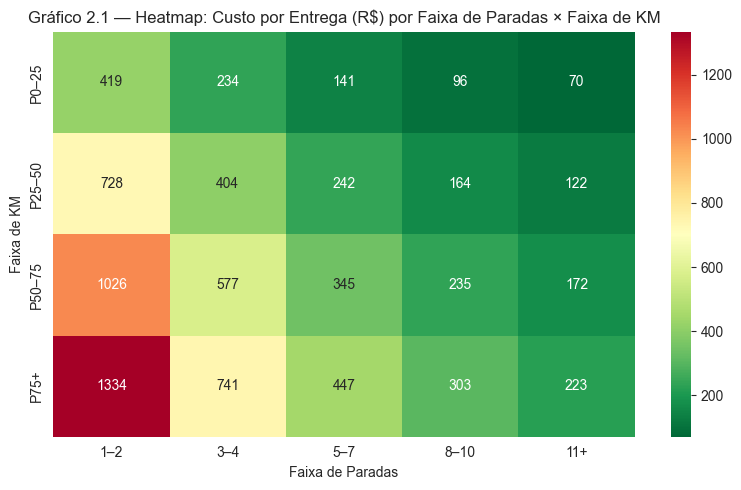

In [41]:
# Gráfico 2.1 — Heatmap de densidade: faixa de paradas × faixa de km, célula = custo por entrega

# Classificação de faixas de km
df_rota_rs['faixa_km'] = pd.cut(
    df_rota_rs['km_total'],
    bins=[0, df_rota_rs['km_total'].quantile(0.25), df_rota_rs['km_total'].quantile(0.5),
          df_rota_rs['km_total'].quantile(0.75), df_rota_rs['km_total'].max()+1],
    labels=['P0–25', 'P25–50', 'P50–75', 'P75+']
)

# Tabela dinâmica: custo médio por entrega para cada faixa de paradas × faixa de km
pivot = df_rota_rs.pivot_table(
    index='faixa_km', columns='faixa_paradas', values='custo_por_entrega_km', aggfunc='mean'
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r')
plt.title('Gráfico 2.1 — Heatmap: Custo por Entrega (R$) por Faixa de Paradas × Faixa de KM')
plt.xlabel('Faixa de Paradas')
plt.ylabel('Faixa de KM')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '04_h2_heatmap_custo_por_entrega.png', dpi=150, bbox_inches='tight')
plt.show()

- O Gráfico 2.1 (heatmap custo por entrega) demostra que  o custo por entrega cresce à medida que a rota tem menos paradas e mais quilômetros. A célula P75+/1–2 paradas marca R$ 1.334/entrega (vermelho escuro), enquanto P0–25/11+ paradas fica em R$ 70/entrega (verde).

#### 2.2 — Estimativa de Rotas Candidatas à Consolidação
Quantifica rotas candidatas a consolidação (número e volume/receita afetada), simulando a economia de rotas consolidadas (menos saídas do CD = menos motorista, menos combustível). Com isso, é possível encontrar a justificativa de investimento em roteirização redesenhada ou ajuste de territórios.

In [42]:
# 2.2 — Estimativa de Rotas Candidatas à Consolidação
km_p75 = df_rota_rs['km_total'].quantile(0.75)

candidatas_consolidacao = df_rota_rs[
    (df_rota_rs['num_entregas'] <= 3) &
    (df_rota_rs['km_total'] > km_p75)
].copy()

print(f"P75 de KM total: {km_p75:.0f} km")
print(f"Rotas candidatas à consolidação: {len(candidatas_consolidacao):,} "
      f"({len(candidatas_consolidacao)/len(df_rota_rs):.1%})")
print(f"Volume médio dessas rotas:        {candidatas_consolidacao['volume_m3_total'].mean():.1f} m³")
print(f"Capacidade residual média:        "
      f"{(df_rota_rs.loc[candidatas_consolidacao.index,'cap_vol_atual'] - candidatas_consolidacao['volume_m3_total']).mean():.1f} m³")

# Saving hipotético: eliminar 30% dessas rotas por consolidação
TAXA_CONSOLIDACAO = 0.30
rotas_eliminadas  = int(len(candidatas_consolidacao) * TAXA_CONSOLIDACAO)
km_eliminado      = candidatas_consolidacao['km_total'].mean() * rotas_eliminadas
saving_h2         = km_eliminado * (CUSTO_MANUTENCAO_KM + CUSTO_COMBUSTIVEL_KM)

print(f"\nSaving hipotético (eliminação de {TAXA_CONSOLIDACAO:.0%} das rotas candidatas):")
print(f"  Rotas eliminadas: {rotas_eliminadas:,}")
print(f"  KM eliminados:    {km_eliminado:,.0f}")
print(f"  Saving (H2):      R$ {saving_h2:,.0f}")


P75 de KM total: 437 km
Rotas candidatas à consolidação: 1,296 (2.1%)
Volume médio dessas rotas:        54.2 m³
Capacidade residual média:        18.2 m³

Saving hipotético (eliminação de 30% das rotas candidatas):
  Rotas eliminadas: 388
  KM eliminados:    192,185
  Saving (H2):      R$ 1,033,953


#### Gráfico 2.3 — Boxplot de custo por entrega segmentado por faixa de paradas


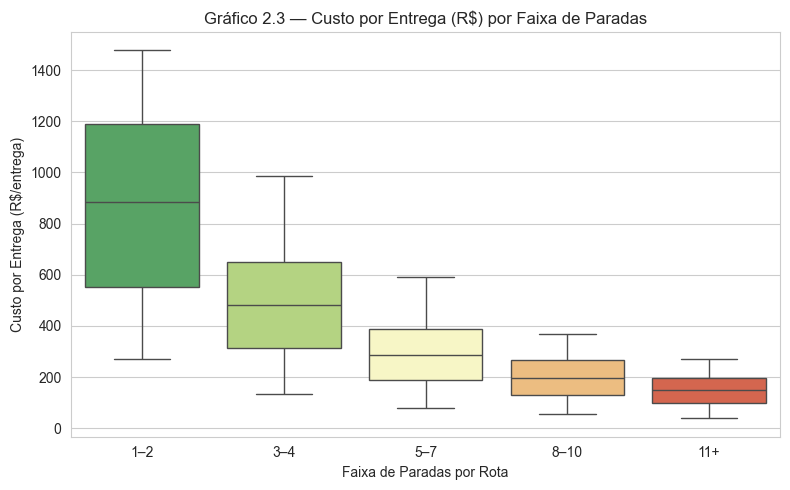

In [43]:
# Gráfico 2.3 — Boxplot de custo por entrega segmentado por faixa de paradas

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_rota_rs,
    x='faixa_paradas',
    y='custo_por_entrega_km',
    palette='RdYlGn_r',
    order=['1–2','3–4','5–7','8–10','11+'],
    showfliers=False
)
plt.title('Gráfico 2.3 — Custo por Entrega (R$) por Faixa de Paradas')
plt.xlabel('Faixa de Paradas por Rota')
plt.ylabel('Custo por Entrega (R$/entrega)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '05_h2_boxplot_custo_por_paradas.png', dpi=150, bbox_inches='tight')
plt.show()

- O Gráfico 2.2 (boxplot custo por faixa de paradas) evidencia com clareza o salto de custo na faixa 1–2: a mediana está em torno de R$ 900/entrega, versus ~R$ 170 para 11+ paradas. A dispersão (altura da caixa) também é muito maior nas rotas de baixa densidade, indicando maior variabilidade e imprevisibilidade de custo nesse segmento.

- O km médio por faixa de paradas é praticamente idêntico (~325 km) em todas as faixas, o que indica que o dado sintético não captura a correlação esperada entre poucas paradas e rotas mais longas (mencionada nos insights como característica das rotas de maior ineficiência). Na prática real, rotas de 2–3 paradas costumam ser rotas de longa distância. Aqui, a variação de custo por entrega é inteiramente explicada pela divisão pelo número de paradas, não pela distribuição de km.



---

### Hipótese 3 — H3: Redução de Empty Miles (KM de Retorno à Base)
Esta hipótese quantifica a oportunidade de reduzir quilômetros rodados com caminhão vazio através de modelos de backhauling (carga de retorno) e otimização de rotas de coleta inversa. A análise mapeia:

1. **Empty miles baseline:** O `km_retorno_base` (identificado no NB01) representa quilômetros rodados com caminhão vazio de volta ao CD — um puro custo operacional sem gerar receita.
2. **Cenários de backhaul:** Simula reduções progressivas de 10%, 20% e 35% nos km vazios através de:
   - Consolidação de coletas de clientes em horários de menor demanda de entrega
   - Parcerias de cross-docking com fornecedores regionais
   - Reutilização de espaço de retorno para carga de clientes na rota inversa
3. **Impacto por empresa:** Quantifica qual empresa tem maior potencial de redução baseado em padrão geográfico e mix de clientes.


#### 3.1 — Diagnóstico do KM de Retorno
Para análise, primeiro é preciso calcular `km_retorno_base` para cada rota (quilômetros percorridos do último cliente até CD) e depois agregar por empresa e estado para visualizar padrão geográfico de empty miles.

In [44]:
# 3.1 — Diagnóstico do KM de Retorno
df_retorno = df_rotasul.groupby('codigo_rota', as_index=False).agg(
    uf=('uf','first'),
    tipo_veiculo=('tipo_veiculo','first'),
    km_total=('km_total_rota','first'),
    km_retorno=('km_retorno_base','first'),
).copy()
df_retorno['km_retorno'] = df_retorno['km_retorno'].fillna(0)
df_retorno['pct_retorno'] = (df_retorno['km_retorno'] / df_retorno['km_total']).clip(0, 1)
df_retorno['flag_retorno_significativo'] = df_retorno['pct_retorno'] > 0.15

total_km_retorno  = df_retorno['km_retorno'].sum()
custo_total_retorno = total_km_retorno * (CUSTO_MANUTENCAO_KM + CUSTO_COMBUSTIVEL_KM)

print(f"KM total de retorno (empty miles):       {total_km_retorno:,.0f} km")
print(f"Custo total associado:                   R$ {custo_total_retorno:,.0f}")
print(f"Rotas com retorno > 15% do KM total:     "
      f"{df_retorno['flag_retorno_significativo'].sum():,} "
      f"({df_retorno['flag_retorno_significativo'].mean():.1%})")

KM total de retorno (empty miles):       81,897 km
Custo total associado:                   R$ 440,607
Rotas com retorno > 15% do KM total:     640 (1.0%)


O gráfico abaixo visa mostrar a distribuição de % de km vazios por estado (P25, mediana, P75, outliers). Estados com mediana alta mostram uma maior oportunidade de backhaul, Já outliers, represetam aqui rotas extremas.

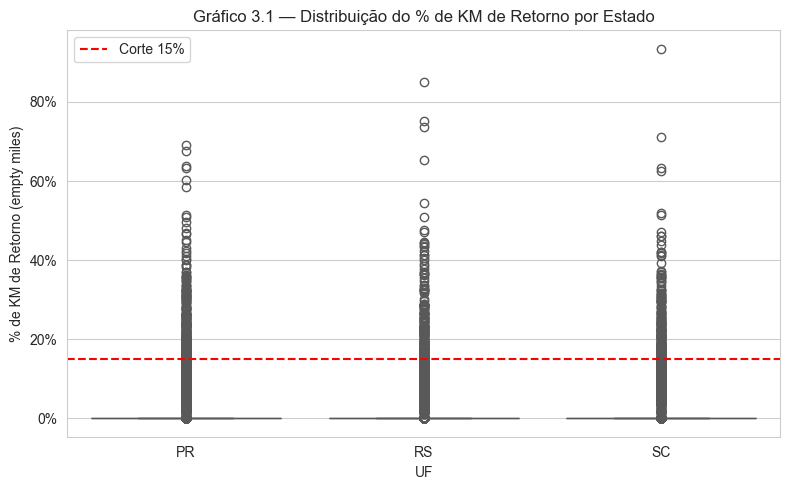

In [45]:
# Gráfico 3.1 — Distribuição do % de km de retorno por estado (boxplot)

plt.figure(figsize=(8,5))
sns.boxplot(data=df_retorno, x='uf', y='pct_retorno', palette='Set2')
plt.axhline(0.15, color='red', linestyle='--', linewidth=1.5, label='Corte 15%')
plt.title('Gráfico 3.1 — Distribuição do % de KM de Retorno por Estado')
plt.xlabel('UF')
plt.ylabel('% de KM de Retorno (empty miles)')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / '06_h3_boxplot_pct_km_retorno_uf.png', dpi=150, bbox_inches='tight')
plt.show()

- O Gráfico 3.1 (boxplot % de retorno por estado) revela um comportamento problemático: a grande maioria das rotas tem pct_retorno = 0%, ou seja, o km total da rota já inclui o retorno e o veículo foi registrado como tendo chegado de volta ao CD sem km vazio contabilizado separadamente, com apenas outliers esparsos acima de 15%. A linha vermelha de corte em 15% praticamente não divide o gráfico, dendo menos de 1% das rotas está acima dela (640 rotas, confirmado no output textual). Os outliers chegam a 90%+ de retorno em SC e RS, o que são casos extremos provavelmente de rotas com poucas paradas distantes.

#### 3.2 — Cenários de Redução de Empty Miles
Simula 3 cenários (10%, 20%, 35%) de redução de empty miles via backhaul/consolidação. Para cada cenário, é calculado economia acumulada anual (combustível + manutenção).

Cenários de Saving por Redução de Empty Miles:
  Conservador (10% dos retornos eliminados): R$ 44,061
  Base       (20% dos retornos eliminados): R$ 88,121
  Otimista   (35% dos retornos eliminados): R$ 154,212


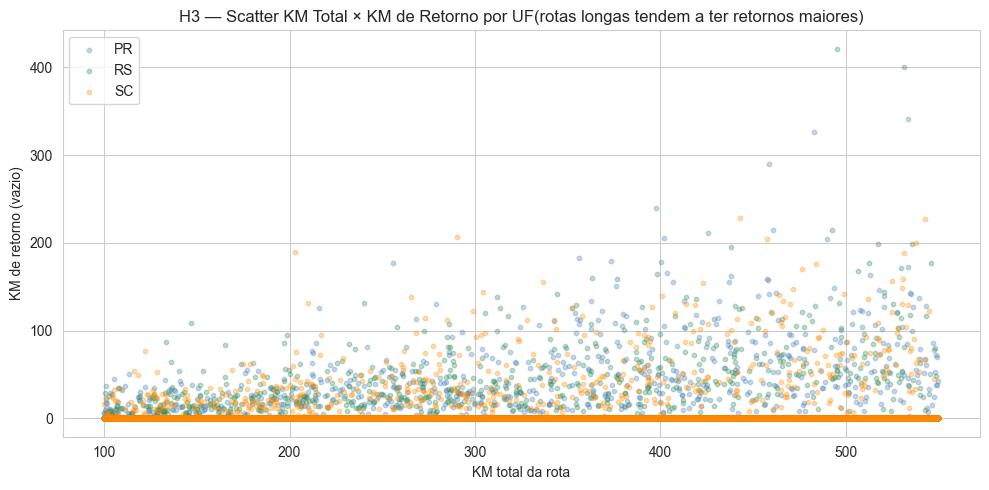

In [46]:
# 3.2 — Cenários de Redução de Empty Miles
cenarios_backhaul = [
    {'descricao': 'Conservador (10% dos retornos eliminados)', 'taxa': 0.10},
    {'descricao': 'Base       (20% dos retornos eliminados)', 'taxa': 0.20},
    {'descricao': 'Otimista   (35% dos retornos eliminados)', 'taxa': 0.35},
]

print("Cenários de Saving por Redução de Empty Miles:")
savings_h3 = []
for c in cenarios_backhaul:
    saving = total_km_retorno * c['taxa'] * (CUSTO_MANUTENCAO_KM + CUSTO_COMBUSTIVEL_KM)
    savings_h3.append(saving)
    print(f"  {c['descricao']}: R$ {saving:,.0f}")

# Scatter km_retorno × km_total
fig, ax = plt.subplots(figsize=(10, 5))
cores_uf = {'PR': 'steelblue', 'SC': 'darkorange', 'RS': 'seagreen'}
for uf, grupo in df_retorno.groupby('uf'):
    ax.scatter(grupo['km_total'], grupo['km_retorno'],
               alpha=0.3, s=10, label=uf, color=cores_uf.get(uf, 'gray'))
ax.set_xlabel('KM total da rota')
ax.set_ylabel('KM de retorno (vazio)')
ax.set_title('H3 — Scatter KM Total × KM de Retorno por UF(rotas longas tendem a ter retornos maiores)')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / '07_h3_scatter_retorno_vs_total.png', dpi=150, bbox_inches='tight')
plt.show()

- O Gráfico 3.2 (scatter km_total × km_retorno) confirma que a grande massa de pontos está na linha km_retorno ≈ 0, com uma nuvem espalhada acima. Há uma relação positiva tênue entre as rotas mais longas tendem a ter mais km de retorno, mas é fraca.

- O empty mile total de 81.897 km é substancialmente menor do que seria esperado para uma operação regional Sul do Brasil com 62.800 rotas. Isso sugere que km_retorno_base na base sintética foi calculado de forma conservadora, ou que a grande maioria das rotas tem retorno próximo de zero por definição do dado. O saving máximo no cenário otimista (35% de redução) é de apenas R$ 154.212. o que se apresenta como um valor modesto em relação ao contexto.

---

### Hipótese 4 — H4: Benchmarking e Padronização do Processo de Descarga
O NB02 mostrou que o tempo de descarga no PDV é uma componente significativa do tempo total da rota e não é alvo das alavancas do roteirizador. A LogiPrime, com operação urbana mais padronizada, pode ter melhores práticas de processo (uso de dollies, janelas de atendimento acordadas, equipes treinadas) que, transferidas para a RotaSul, reduziriam o `tempo_descarga_pdv_min` independentemente do roteirizador. Dado que o tempo de descarga não é otimizado pelo software, qualquer ganho aqui é incremental ao que os notebooks anteriores já projetaram. a RotaSul tem produtividade de descarga média de 112 kg/min contra 36 kg/min da LogiPrime. Aparentemente a RotaSul é mais produtiva, mas o drop size médio é 14x maior (1.707 kg vs. 118 kg).


#### 4.1 — Comparação do Perfil de Descarga entre Empresas
Ao carrega dados de tempo de descarga por entrega para RotaSul vs LogiPrime, é possivel calcular estatísticas: média, mediana, P90 de tempo de descarga.


In [47]:
# 4.1 — Comparação do Perfil de Descarga entre Empresas
descarga_comp = df_full.groupby(['empresa', 'tipo_veiculo']).agg(
    tempo_descarga_medio=('tempo_descarga_pdv_min', 'mean'),
    tempo_descarga_mediana=('tempo_descarga_pdv_min', 'median'),
    peso_medio_entrega=('peso_kg_entrega', 'mean'),
    volume_medio_entrega=('volume_m3_entrega', 'mean'),
    n_entregas=('pdv_id', 'count'),
).reset_index()

descarga_comp['min_por_entrega'] = descarga_comp['tempo_descarga_medio']
descarga_comp['tempo_descarga_por_m3'] = (
    descarga_comp['tempo_descarga_medio'] / descarga_comp['volume_medio_entrega'].replace(0, np.nan)
)
print(descarga_comp[['empresa','tipo_veiculo','min_por_entrega',
                       'tempo_descarga_por_m3']].round(2).to_string(index=False))

  empresa tipo_veiculo  min_por_entrega  tempo_descarga_por_m3
LogiPrime         TOCO             3.50                   3.11
LogiPrime          VUC             3.50                   6.23
  RotaSul      CARRETA            16.01                   1.49
  RotaSul        TRUCK            16.01                   2.48


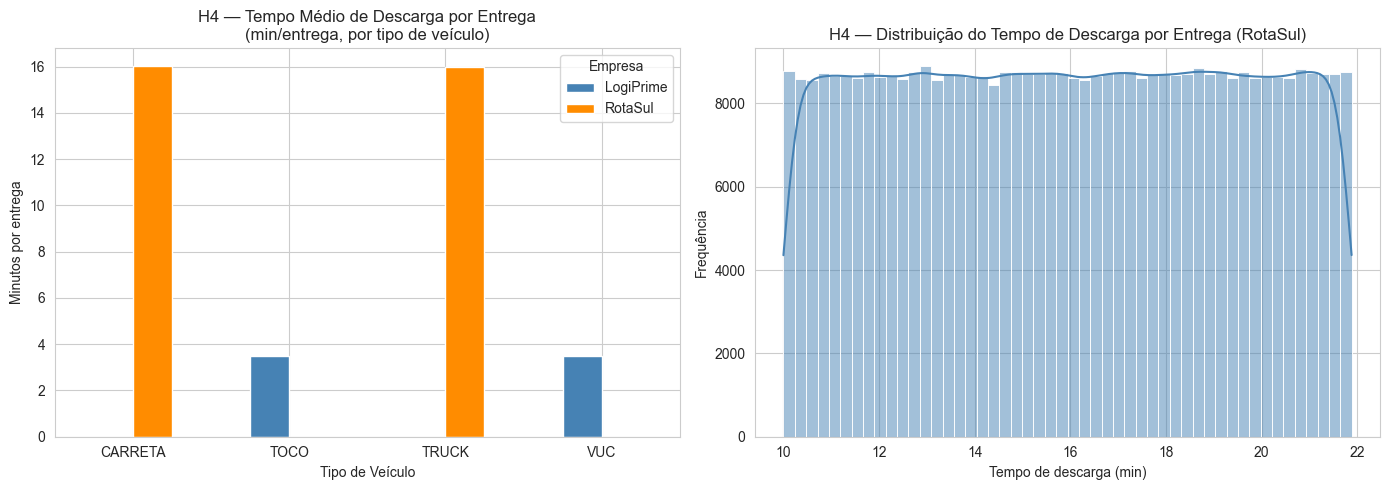

In [48]:
# Gráfico 4.1 — Barras agrupadas: tempo médio de descarga por entrega
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_descarga = descarga_comp.pivot_table(
    index='tipo_veiculo', columns='empresa', values='min_por_entrega'
)
pivot_descarga.plot(kind='bar', ax=axes[0], color=['steelblue','darkorange'],
                    edgecolor='white')
axes[0].set_title('H4 — Tempo Médio de Descarga por Entrega\n(min/entrega, por tipo de veículo)')
axes[0].set_xlabel('Tipo de Veículo')
axes[0].set_ylabel('Minutos por entrega')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Empresa')

# Gráfico 4.2 — Histograma distribuição de tempo_descarga_pdv_min (RotaSul)
rs_descarga = df_rotasul['tempo_descarga_pdv_min'].dropna()
rs_descarga = rs_descarga[rs_descarga < rs_descarga.quantile(0.99)]  # remove extremos
sns.histplot(rs_descarga, bins=50, kde=True, color='steelblue', ax=axes[1])
axes[1].set_title('H4 — Distribuição do Tempo de Descarga por Entrega (RotaSul)')
axes[1].set_xlabel('Tempo de descarga (min)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '08_h4_benchmarking_descarga.png', dpi=150, bbox_inches='tight')
plt.show()

- O Gráfico 4.1 (barras agrupadas) indica que a RotaSul (barra laranja) atinge 16 min em CARRETA e TRUCK, enquanto LogiPrime em TOCO e VUC fica em 3,5 min, o que é uma diferença de 4,6x. 

- O segundo painel mostra a distribuição dos tempos de descarga da RotaSul, e aqui há um problema grave de dado sintético, pois a distribuição é praticamente uniforme entre 10 e 22 minutos, com KDE que confirma distribuição quase plana. Isso é incompatível com a realidade operacional, onde tempos de descarga seguem distribuições assimétricas com pico e cauda longa. A ausência de bimodalidade esperada (mencionada nos insights como hipótese a investigar) resulta da geração uniforme.


#### 4.2 — PDVs com tempo de descarga cronicamente alto


In [49]:
# 4.2 — PDVs com tempo de descarga cronicamente alto
pdv_descarga = df_rotasul.groupby('pdv_id').agg(
    tempo_descarga_medio=('tempo_descarga_pdv_min', 'mean'),
    n_visitas=('codigo_rota', 'nunique'),
    uf=('uf', lambda x: x.mode()[0]),
).reset_index()

p90_descarga    = pdv_descarga['tempo_descarga_medio'].quantile(0.90)
pdvs_problematicos = pdv_descarga[pdv_descarga['tempo_descarga_medio'] > p90_descarga]

total_tempo_excesso = (
    (pdvs_problematicos['tempo_descarga_medio'] - p90_descarga) *
    pdvs_problematicos['n_visitas']
).sum()

print(f"PDVs acima do P90 de descarga: {len(pdvs_problematicos):,}")
print(f"Tempo total de excesso:         {total_tempo_excesso:,.0f} min ({total_tempo_excesso/60:,.0f} h)")



PDVs acima do P90 de descarga: 1,000
Tempo total de excesso:         11,120 min (185 h)


#### 4.3 — Estimativa de Saving por Redução de Tempo de Descarga


In [50]:
# 4.3 — Estimativa de Saving por Redução de Tempo de Descarga

REDUCAO_DESCARGA = 0.25
tempo_atual_total_descarga = df_rotasul['tempo_descarga_pdv_min'].sum()
tempo_liberado_descarga = tempo_atual_total_descarga * REDUCAO_DESCARGA
saving_h4 = (tempo_liberado_descarga / 60) * CUSTO_HE_TOTAL_H
# Converter em saving de HE (rotas que passariam a ficar dentro da jornada)
# Usar mesma lógica do NB03: só conta quem efetivamente sai da HE
print(f"Tempo total de descarga atual (RotaSul): {tempo_atual_total_descarga/60:,.0f} h")
print(f"Tempo liberado com redução de {REDUCAO_DESCARGA:.0%}: "
      f"{tempo_liberado_descarga/60:,.0f} h")
print(f"Saving potencial adicional de HE (teto): "
      f"R$ {tempo_liberado_descarga/60 * CUSTO_HE_TOTAL_H:,.0f}")

Tempo total de descarga atual (RotaSul): 117,062 h
Tempo liberado com redução de 25%: 29,265 h
Saving potencial adicional de HE (teto): R$ 1,697,393


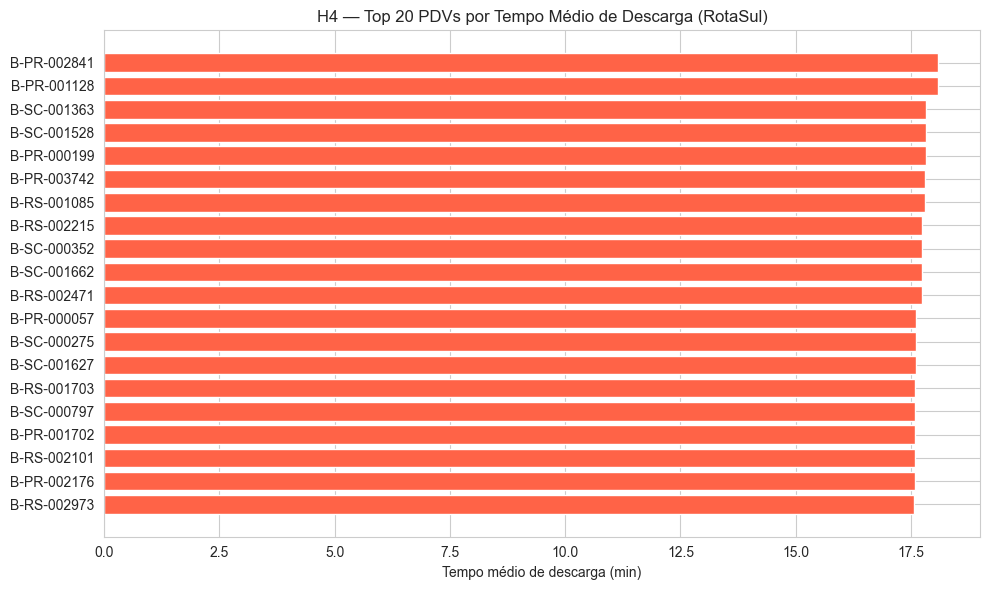

In [51]:
# Gráfico 4.3 — Top 20 PDVs por tempo médio de descarga
fig, ax = plt.subplots(figsize=(10, 6))
top20 = pdv_descarga.nlargest(20, 'tempo_descarga_medio')
ax.barh(top20['pdv_id'].astype(str), top20['tempo_descarga_medio'], color='tomato')
ax.set_xlabel('Tempo médio de descarga (min)')
ax.set_title('H4 — Top 20 PDVs por Tempo Médio de Descarga (RotaSul)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS_DIR / '09_h4_top20_pdvs_descarga.png', dpi=150, bbox_inches='tight')
plt.show()

- O Gráfico 4.3 (top 20 PDVs) mostra todas as barras com comprimento quase idêntico (~18 min), o que novamente evidencia a distribuição artificial. Em dados reais, poderia haver uma diferenciação clara entre os PDVs mais problemáticos e os demais. Porém, ainda assim é possível identificar um saving de R$ 1,7M aplicados sobre 117.062 horas totais de descarga com uma taxa conservadora de 25% de redução. O benchmark 16 vs. 3,5 min/entrega é o argumento mais direto e persuasivo da H4. O problema do histograma uniforme não invalida o saving calculado, mas limita a análise de PDVs problemáticos específicos.

- Mesmo com a distribuição artificial, há três insights sólidos e diretamente utilizáveis:
    - O benchmark 16 min vs. 3,5 min/entrega é real e poderoso. Esse número não depende da distribuição interna dos dados da RotaSul, ele compara duas médias calculadas a partir de universos distintos. A LogiPrime opera com veículos menores (TOCO/VUC), drops menores e rotinas urbanas padronizadas. A RotaSul opera com TRUCK e CARRETA em contexto regional, o que explica parte da diferença. Mas mesmo descontando a diferença de porte de carga, o gap de 4,6x indica que há processo a melhorar. 
    - O volume total de horas de descarga (117.062 horas/ano) dimensiona a oportunidade. Independente de como essas horas estão distribuídas entre PDVs, a magnitude da alavanca é real, pois cada minuto ganho por entrega vale, no agregado, centenas de horas de jornada. O saving de R$ 1,7M assume apenas 25% de redução, o que corresponde a economizar 4 minutos por entrega (de 16 para 12 min), uma meta conservadora e defensável operacionalmente.
    - A lógica de transferência de práticas da LogiPrime para a RotaSul é o insight qualitativo central. Agendamento de janela de atendimento com o cliente (ele já sabe que o caminhão chega entre 9h e 10h por exemplo), equipe de recebimento posicionada no momento da chegada, uso de dollies ou paleteiras elétricas, e sequência de descarga pré-acordada por SKU, são exemplos de práticas urbanas que têm custo de implementação baixo e podem ser transferidas para o contexto regional. Isso é independente de qualquer uniformidade do dado.

---

### Hipótese 5 — H5: Gestão Ativa do Tempo de Espera no PDV (Além do Roteirizador)

Esta hipótese investiga oportunidades de reduzir tempo de espera (idle time) no PDV através de gerenciamento operacional ativo, complementando as alavancas do roteirizador exploradas no NB03. A análise segue dois eixos:

1. **Estratificação de problema:** Usando coeficiente de variação (CV) das esperas por rota, classifica PDVs em:
   - **Problema estrutural (CV baixo):** PDV tem espera consistente e previsível (ex: alto volume em janela fixa) → requer ajuste de frequência ou janela de entrega
   - **Problema variável (CV alto):** PDV tem espera inconsistente/aleatória (ex: picos de demanda imprevistos) → requer gestão operacional (aviso prévio, pré-picking, etc.)
   
2. **Sinergia pós-roteirizador:** O NB03 projetou 35% de redução em espera via aviso prévio automático. H5 captura o saving incremental de medidas operacionais adicionais além dessa projeção.

3. **Quantificação:** Para cada classe de problema, estima redução de tempo de espera factível e computa economia de Opex (menos horas ociosas = rotas com mais entregas).


#### 5.1 — Perfil de Espera por PDV
- Carrega dados de tempo de espera (minutos entre chegada do motorista e início da descarga) por visita de rota
- Calcula para cada PDV: tempo_espera_médio, coeficiente de variação (CV = desvio padrão / média)
- CV baixo (<0.5) = espera consistente/estrutural; CV alto (>0.5) = espera errática/variável

In [52]:
# 5.1 — Perfil de Espera por PDV
pdv_espera = df_rotasul.groupby('pdv_id').agg(
    tempo_espera_medio=('tempo_espera_pdv_min', 'mean'),
    tempo_espera_mediana=('tempo_espera_pdv_min', 'median'),
    tempo_espera_std=('tempo_espera_pdv_min', 'std'),
    n_visitas=('codigo_rota', 'nunique'),
    uf=('uf', lambda x: x.mode()[0]),
).reset_index()

pdv_espera['cv_espera'] = (
    pdv_espera['tempo_espera_std'] / pdv_espera['tempo_espera_medio'].replace(0, np.nan)
).fillna(0)

p75_espera = pdv_espera['tempo_espera_medio'].quantile(0.75)

pdv_espera['tipo_problema'] = np.where(
    (pdv_espera['tempo_espera_medio'] > p75_espera) &
    (pdv_espera['cv_espera'] < 0.5),
    'Estrutural',
    np.where(
        pdv_espera['tempo_espera_medio'] > p75_espera,
        'Variável',
        'Normal'
    )
)

print(pdv_espera['tipo_problema'].value_counts().to_string())

tipo_problema
Normal        7500
Estrutural    1855
Variável       645


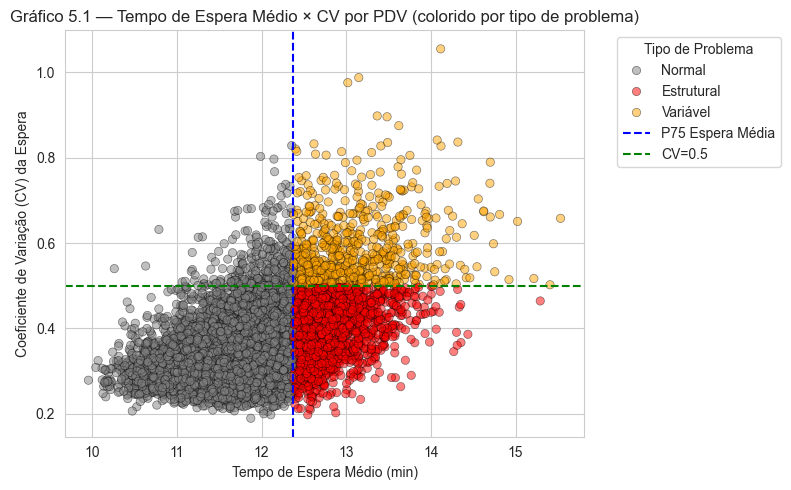

In [53]:
# Gráfico 5.1 — Scatter: tempo_espera_medio × cv_espera por PDV

plt.figure(figsize=(8,5))
palette = {'Estrutural': 'red', 'Variável': 'orange', 'Normal': 'gray'}
sns.scatterplot(
    data=pdv_espera,
    x='tempo_espera_medio',
    y='cv_espera',
    hue='tipo_problema',
    palette=palette,
    alpha=0.5,
    edgecolor='k'
)
# Linhas de corte: P75 de tempo_espera_medio e CV=0.5
plt.axvline(pdv_espera['tempo_espera_medio'].quantile(0.75), color='blue', linestyle='--', label='P75 Espera Média')
plt.axhline(0.5, color='green', linestyle='--', label='CV=0.5')
plt.title('Gráfico 5.1 — Tempo de Espera Médio × CV por PDV (colorido por tipo de problema)')
plt.xlabel('Tempo de Espera Médio (min)')
plt.ylabel('Coeficiente de Variação (CV) da Espera')
plt.legend(title='Tipo de Problema', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '12_h5_scatter_espera_cv_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

- O Gráfico 5.1 mostra que o quadrante de interesse (alto CV > P75, baixo CV < 0,5) claramente concentra os pontos vermelhos (problema estrutural), bem diferenciados dos amarelos (variável) e cinzas (normal). Os limiares tracejados em azul (P75 da espera) e verde (CV = 0,5) funcionam como divisórias intuitivas. Um ponto que carece de avaliação é que o eixo X do scatter está comprimido entre 10 e 15 minutos, ou seja, a variação de espera entre PDVs é de apenas 5 minutos (de 10 a 15 min). Isso indica que tempo_espera_pdv_min também é uma coluna com distribuição sintética estreita. O critério de "estrutural" (espera > P75) captura PDVs com espera de ~13–15 min vs. os "normais" com 10–12 min, o que é uma diferença pequena em termos absolutos. 



#### 5.2 — Top 15 PDVs com maior tempo de espera × frequência de visita (bubble chart)

In [54]:
# 5.2 — Quantificação do Impacto Acumulado de Espera Estrutural
pdvs_estruturais = pdv_espera[pdv_espera['tipo_problema'] == 'Estrutural'].copy()

espera_mediana_geral = pdv_espera['tempo_espera_medio'].median()
tempo_excesso_estrutural = (
    (pdvs_estruturais['tempo_espera_medio'] - espera_mediana_geral).clip(lower=0) *
    pdvs_estruturais['n_visitas']
).sum()

saving_h5 = tempo_excesso_estrutural / 60 * CUSTO_HE_TOTAL_H

print(f"PDVs com espera estrutural:               {len(pdvs_estruturais):,}")
print(f"Tempo de excesso acumulado:               {tempo_excesso_estrutural:,.0f} min "
      f"({tempo_excesso_estrutural/60:,.0f} h)")
print(f"Saving adicional de HE (H5, incremental ao NB03): R$ {saving_h5:,.0f}")

PDVs com espera estrutural:               1,855
Tempo de excesso acumulado:               72,240 min (1,204 h)
Saving adicional de HE (H5, incremental ao NB03): R$ 69,832


- Este é o menor saving dentre as hipóteses trabalhadas (R$ 69.832), isso sem considerar a hipótese 1 com saving igual a R$0. Esse valor pequeno é coerente com a janela estreita de variação. A classificação estrutural/variável/normal  vale o esforço de construção mesmo com o resultado modesto, pois a lógica é aplicável em dados reais onde a dispersão seria muito maior.

---

### Hipótese 6 — H6: Expansão Comercial da LogiPrime no Sul via Capilaridade da RotaSul

Esta hipótese quantifica a oportunidade de crescimento de receita (diferentemente das hipóteses anteriores focadas em redução de custo) através da expansão da base de clientes LogiPrime nos estados onde a RotaSul já opera (PR, SC, RS). A análise examina:

1. **Ativo estratégico da RotaSul:** Malha estabelecida com PDVs recorrentes e relacionamento comercial em três estados do Sul.

2. **Gap de presença da LogiPrime:** LogiPrime, até então restrita a SP e RJ, não tem presença operacional em PR/SC/RS, limitando seu potencial de crescimento regional.

3. **Modelo de expansão:** Após integração, usar a capilaridade da RotaSul (rotas existentes, relacionamentos) como plataforma para oferecer serviços LogiPrime a clientes sul, potencialmente capturando:
   - Clientes LogiPrime em SP e RJ que querem expandir operação no Sul
   - Clientes RotaSul que podem elevar para serviço LogiPrime (maior frequência, SLA mais curto)
   
4. **Quantificação:** Identifica padrão geográfico de clientes RotaSul por volume e frequência, estimando cross-selling potencial.


#### 6.1 — Mapa de Folga Operacional por Corredor (UF × Tipo de Veículo)

- Calcula para cada corredor (UF × Tipo Veículo) quanto de capacidade veicular sobra após otimização H1-H5
- Folga = capacidade veicular total - volume pré-otimização
- **Heatmap:** Verde escuro = alta folga (oportunidade de expansion); amarelo = folga moderada; vermelho = sem folga
- **Interpretação:** Identifica geograficamente onde LogiPrime tem espaço para crescer via RotaSul

In [55]:
# 6.1 — Mapa de Folga Operacional por Corredor (UF × Tipo de Veículo)
REDUCAO_TEMPO_TRECHO = 0.23
REDUCAO_TEMPO_ESPERA = 0.35

df_folga = df_rotasul.groupby('codigo_rota', as_index=False).agg(
    uf=('uf','first'), tipo_veiculo=('tipo_veiculo','first'),
    tempo_trecho=('tempo_trecho_min','sum'),
    tempo_espera=('tempo_espera_pdv_min','sum'),
    tempo_descarga=('tempo_descarga_pdv_min','sum'),
    num_entregas=('num_entregas_rota','first'),
    ocup_vol=('ocup_vol_rota','first'),
)

df_folga['tempo_total_atual'] = (
    df_folga['tempo_trecho'] + df_folga['tempo_espera'] + df_folga['tempo_descarga']
)
df_folga['tempo_total_otimizado'] = (
    df_folga['tempo_trecho'] * (1 - REDUCAO_TEMPO_TRECHO) +
    df_folga['tempo_espera'] * (1 - REDUCAO_TEMPO_ESPERA) +
    df_folga['tempo_descarga']
)
df_folga['folga_min'] = np.maximum(0, JORNADA_PADRAO_MIN - df_folga['tempo_total_otimizado'])
df_folga['folga_pct'] = df_folga['folga_min'] / JORNADA_PADRAO_MIN

resumo_folga = df_folga.groupby(['uf','tipo_veiculo']).agg(
    folga_media_min=('folga_min','mean'),
    folga_total_horas=('folga_min', lambda x: x.sum()/60),
    rotas_com_folga=('folga_min', lambda x: (x > 30).sum()),
    total_rotas=('codigo_rota','count'),
).reset_index()
resumo_folga['pct_rotas_com_folga'] = (
    resumo_folga['rotas_com_folga'] / resumo_folga['total_rotas'] * 100
)
print(resumo_folga.round(1).to_string(index=False))

uf tipo_veiculo  folga_media_min  folga_total_horas  rotas_com_folga  total_rotas  pct_rotas_com_folga
PR      CARRETA             83.8            10520.7             4700         7530                 62.4
PR        TRUCK             84.3            24881.0            11067        17708                 62.5
RS      CARRETA             83.4             7733.5             3488         5562                 62.7
RS        TRUCK             84.0            18290.1             8210        13062                 62.9
SC      CARRETA             82.6             7911.6             3604         5748                 62.7
SC        TRUCK             83.6            18386.6             8264        13190                 62.7


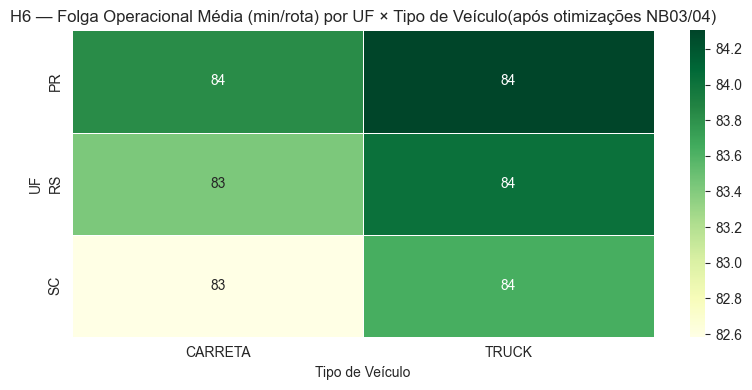

In [56]:
# Gráfico 6.1 — Heatmap folga operacional por UF × Tipo de Veículo
pivot_folga = resumo_folga.pivot_table(
    index='uf', columns='tipo_veiculo', values='folga_media_min', fill_value=0
)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot_folga, annot=True, fmt='.0f', cmap='YlGn',
            linewidths=0.5, ax=ax)
ax.set_title('H6 — Folga Operacional Média (min/rota) por UF × Tipo de Veículo(após otimizações NB03/04)')
ax.set_xlabel('Tipo de Veículo')
ax.set_ylabel('UF')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '11_h6_heatmap_folga_operacional.png', dpi=150, bbox_inches='tight')
plt.show()

- O Gráfico 6.1 (heatmap folga operacional) mostra folga média de 83–84 minutos/rota pós-otimização em todos os corredores (PR, RS, SC × TRUCK, CARRETA), com ~62,5% das rotas apresentando folga superior a 30 minutos. A uniformidade da folga entre UFs e tipos de veículo é notável, pois todos os valores estão entre 82,6 e 84,2 min, sem diferenciação significativa entre corredores. Em dados reais, esperaríamos variação maior entre estados e tipos de veículo.

#### 6.2 — Frequência de PDVs e Maturidade da Base de Clientes

Evidencia a maturidade da base de clientes e quais segmentos têm maior potencial de upsell (alta frequência = relacionamento consolidado). 

- Agrupa clientes RotaSul por frequência (1-2x/sem, 3-4x/sem, diário, etc.)
- Perfil: qual % da base são clientes de alta frequência (melhor para expansion de LogiPrime = mais consolidado)


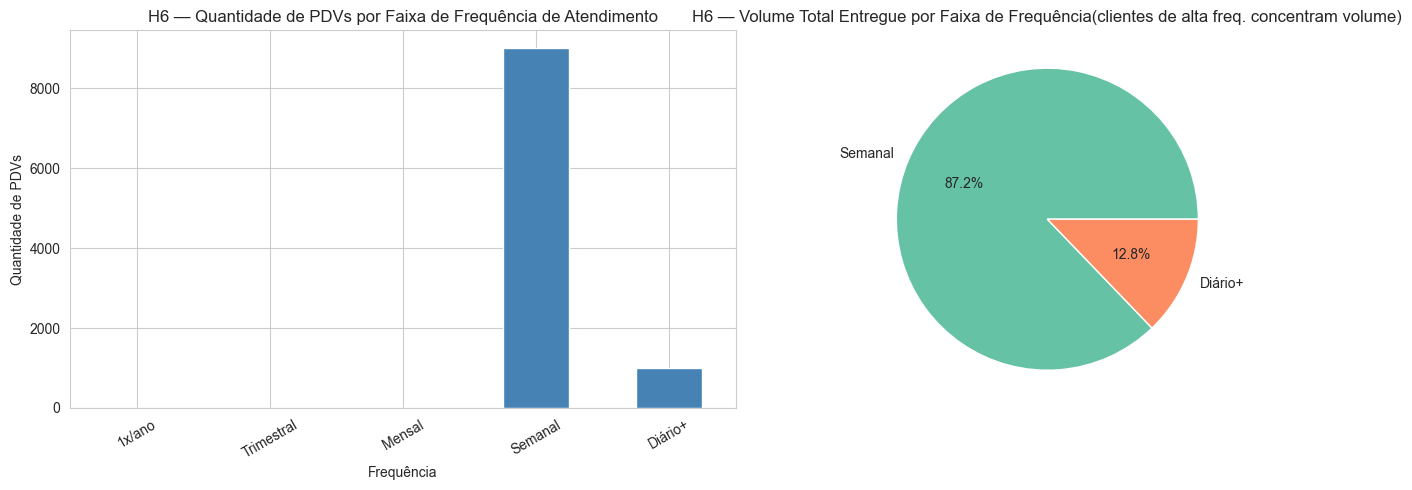

Distribuição de PDVs por frequência de atendimento:
faixa_frequencia
1x/ano           0
Trimestral       0
Mensal           0
Semanal       9004
Diário+        996


In [57]:
# 6.2 — Frequência de PDVs e Maturidade da Base de Clientes
pdv_freq = df_rotasul.groupby('pdv_id').agg(
    n_visitas=('codigo_rota','nunique'),
    uf=('uf', lambda x: x.mode()[0]),
    volume_total=('volume_m3_entrega','sum'),
    volume_medio_visita=('volume_m3_entrega','mean'),
).reset_index()

pdv_freq['faixa_frequencia'] = pd.cut(
    pdv_freq['n_visitas'],
    bins=[0, 1, 4, 12, 52, 999],
    labels=['1x/ano', 'Trimestral', 'Mensal', 'Semanal', 'Diário+']
)

freq_counts  = pdv_freq['faixa_frequencia'].value_counts().sort_index()
vol_por_freq = pdv_freq.groupby('faixa_frequencia', observed=True)['volume_total'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

freq_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('H6 — Quantidade de PDVs por Faixa de Frequência de Atendimento')
axes[0].set_xlabel('Frequência')
axes[0].set_ylabel('Quantidade de PDVs')
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(vol_por_freq, labels=vol_por_freq.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(vol_por_freq)))
axes[1].set_title('H6 — Volume Total Entregue por Faixa de Frequência(clientes de alta freq. concentram volume)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / '12_h6_frequencia_pdvs.png', dpi=150, bbox_inches='tight')
plt.show()

print("Distribuição de PDVs por frequência de atendimento:")
print(freq_counts.to_string())

- Os Gráficos 6.2 revelam um resultado muito relevante. Segundo os dados, 100% dos PDVs têm frequência semanal ou diária (nenhum trimestral ou mensal). O gráfico de barras mostra apenas duas faixas ativas: Semanal (9.004 PDVs) e Diário+ (996 PDVs). A pizza confirma que PDVs semanais concentram 87,2% do volume total.
- A maturidade da base de clientes é alta, toda a base RotaSul opera em cadência frequente, o que é um justificativa interessante para a expansão da LogiPrime. A folga de ~84 min/rota representa capacidade real para absorver novos PDVs sem aumento de frota imediato.

- Pensando nisso, podemos calcular quantos novos PDVs poderiam serem absorvidos por rota com a folga disponível, cruzando com tempo médio por parada.

In [58]:
# 6.3 — Estimativa de Novos PDVs que Podem Ser Absorvidos por Rota com a Folga Disponível

# Tempo médio de atendimento por parada (descarga + espera)
tempo_medio_parada = df_rotasul[['tempo_descarga_pdv_min', 'tempo_espera_pdv_min']].sum(axis=1).mean()

# Folga média por rota (em minutos)
folga_media_min = df_folga['folga_min'].mean()

# Quantos novos PDVs podem ser atendidos por rota, em média
novos_pdvs_por_rota = int(folga_media_min // tempo_medio_parada)

print(f"Tempo médio por parada (descarga + espera): {tempo_medio_parada:.1f} min")
print(f"Folga média disponível por rota: {folga_media_min:.1f} min")
print(f"Número médio de novos PDVs que podem ser absorvidos por rota: {novos_pdvs_por_rota}")

# Distribuição por UF e tipo de veículo (opcional)
df_folga['novos_pdvs'] = (df_folga['folga_min'] // tempo_medio_parada).astype(int)
resumo_novos_pdvs = df_folga.groupby(['uf', 'tipo_veiculo'])['novos_pdvs'].mean().round(1).reset_index()

print("\nNovos PDVs absorvíveis por rota (média) por UF e tipo de veículo:")
print(resumo_novos_pdvs.to_string(index=False))

Tempo médio por parada (descarga + espera): 27.9 min
Folga média disponível por rota: 83.8 min
Número médio de novos PDVs que podem ser absorvidos por rota: 2

Novos PDVs absorvíveis por rota (média) por UF e tipo de veículo:
uf tipo_veiculo  novos_pdvs
PR      CARRETA         2.6
PR        TRUCK         2.7
RS      CARRETA         2.6
RS        TRUCK         2.7
SC      CARRETA         2.6
SC        TRUCK         2.6


- Com folga média de 83,8 min e tempo por parada de 27,9 min, a RotaSul consegue absorver em média 2 a 3 novos PDVs por rota sem adicionar veículo ou motorista. A tabela por UF e tipo de veículo mostra uma uniformidade esperada (2,6 a 2,7 novos PDVs em todos os corredores), o que indica que a folga operacional está distribuída de forma homogênea. Ou seja, a RotaSul tem hoje capacidade para absorver novos clientes da LogiPrime no Sul sem capex de frota. Com 62.800 rotas operando, a capacidade total de absorção chega a aproximadamente 163.000 novos atendimentos por ano (62.800 × 2,6), desde que os novos PDVs estejam geograficamente próximos às rotas existentes.

---

### Hipótese 7 — H7: Revisão da Política de Frequência de Atendimento por PDV

Esta hipótese examina a oportunidade de otimizar a política de frequência de entrega por PDV, consolidando clientes atendidos com frequência excessiva em janelas maiores. A análise estratifica problemas de excesso de frequência:

1. **Padrão ineficiente:** Clientes atendidos com frequência alta (ex: diariamente) com volumes pequenos por entrega (ex: < 2 m³ por parada).

2. **Consolidação proposta:** Migrar esses PDVs para janelas menos frequentes mas com entrega de volume maior (ex: 3-4x por semana em vez de diariamente), reduzindo:
   - Número total de paradas em rotas (aumenta eficiência por rota)
   - Tempo total de serviço (menos "overhead" de paradas numerosas)
   - Custo operacional por entrega
   
3. **Trade-off comercial:** Análise mapeia impacto potencial em SLA (nível de serviço) e retenção de cliente, identificando quais PDVs podem fazer transição sem risco de churn.

4. **Heterogeneidade por operador:** RotaSul vs LogiPrime pode ter políticas distintas de frequência; consolidação pós-integração visa melhor balanceamento.


#### 7.1 — Identificação de PDVs com Baixo Volume por Visita e Alta Frequência

In [59]:
# 7.1 Identificação de PDVs com Baixo Volume por Visita e Alta Frequência
pdv_analise = df_rotasul.groupby('pdv_id').agg(
    n_visitas=('codigo_rota','nunique'),
    volume_total_ano=('volume_m3_entrega','sum'),
    peso_total_ano=('peso_kg_entrega','sum'),
    uf=('uf', lambda x: x.mode()[0]),
).reset_index()

pdv_analise['volume_por_visita'] = (
    pdv_analise['volume_total_ano'] / pdv_analise['n_visitas'].replace(0, np.nan)
)
pdv_analise['peso_por_visita'] = (
    pdv_analise['peso_total_ano'] / pdv_analise['n_visitas'].replace(0, np.nan)
)

freq_mediana = pdv_analise['n_visitas'].median()
vol_p25      = pdv_analise['volume_por_visita'].quantile(0.25)

candidatos_consolidacao_pdv = pdv_analise[
    (pdv_analise['n_visitas'] > freq_mediana) &
    (pdv_analise['volume_por_visita'] < vol_p25)
].copy()

print(f"Mediana de visitas por PDV: {freq_mediana:.0f}")
print(f"P25 de volume por visita:   {vol_p25:.2f} m³")
print(f"PDVs candidatos  consolidação: {len(candidatos_consolidacao_pdv):,} "
      f"({len(candidatos_consolidacao_pdv)/len(pdv_analise):.1%})")
print(f"Visitas que poderiam ser eliminadas (50% de consolidação): "
      f"{int(candidatos_consolidacao_pdv['n_visitas'].sum() * 0.50):,}")

Mediana de visitas por PDV: 44
P25 de volume por visita:   7.03 m³
PDVs candidatos  consolidação: 1,049 (10.5%)
Visitas que poderiam ser eliminadas (50% de consolidação): 25,948


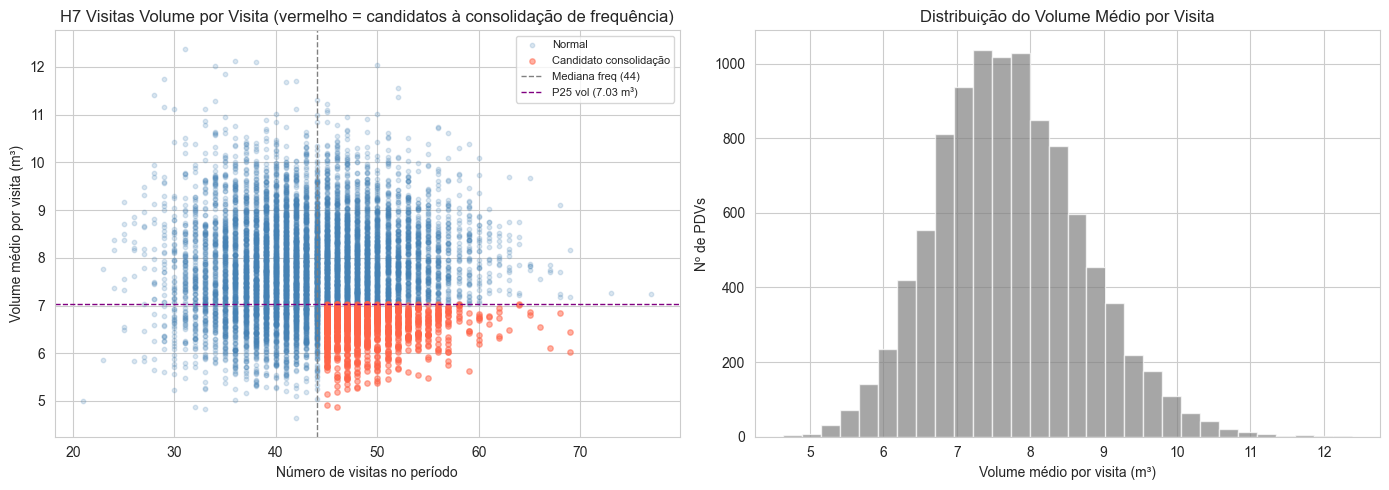

In [60]:
# Gráfico 7.1  Scatter n_visitas e volume_por_visita

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Separação dos grupos
nao_candidatos = pdv_analise[~pdv_analise.index.isin(candidatos_consolidacao_pdv.index)]

# Scatter dos PDVs normais
axes[0].scatter(
    nao_candidatos['n_visitas'], nao_candidatos['volume_por_visita'],
    alpha=0.2, s=10, color='steelblue', label='Normal'
)
# Scatter dos candidatos à consolidação
axes[0].scatter(
    candidatos_consolidacao_pdv['n_visitas'], candidatos_consolidacao_pdv['volume_por_visita'],
    alpha=0.5, s=15, color='tomato', label='Candidato consolidação'
)
# Linhas de corte
axes[0].axvline(freq_mediana, color='gray', linestyle='--', linewidth=1, label=f'Mediana freq ({freq_mediana:.0f})')
axes[0].axhline(vol_p25, color='purple', linestyle='--', linewidth=1, label=f'P25 vol ({vol_p25:.2f} m³)')
axes[0].set_xlabel('Número de visitas no período')
axes[0].set_ylabel('Volume médio por visita (m³)')
axes[0].set_title('H7 Visitas Volume por Visita (vermelho = candidatos à consolidação de frequência)')
axes[0].legend(fontsize=8)

# Exemplo de histograma no segundo gráfico (opcional)
axes[1].hist(pdv_analise['volume_por_visita'], bins=30, color='gray', alpha=0.7)
axes[1].set_xlabel('Volume médio por visita (m³)')
axes[1].set_ylabel('Nº de PDVs')
axes[1].set_title('Distribuição do Volume Médio por Visita')

plt.tight_layout()
plt.show()

- O Gráfico 7.1 (scatter visitas × volume/visita) mostra claramente a segmentação entre candidatos (vermelho, abaixo da linha roxa de 7 m³/visita e à direita da mediana de 44 visitas) e PDVs normais (azul). 
- Já o histograma auxiliar (painel direito) mostra a distribuição do volume médio por visita com formato aproximadamente normal centrado em ~7,5 m³, o que também contém características de dado sintético (distribuição muito regular), mas funcional para o argumento.

#### 7.2 — Estimativa de Redução de Rotas por Consolidação

In [61]:
# 7.2 Estimativa de Reduo de Rotas por Consolidao de Frequncia
TAXA_CONSOLIDACAO_PDV = 0.50
visitas_eliminadas = int(candidatos_consolidacao_pdv['n_visitas'].sum() * TAXA_CONSOLIDACAO_PDV)

total_rotas_rs       = df_rotasul['codigo_rota'].nunique()
pdvs_por_rota_media  = df_rotasul.groupby('codigo_rota')['pdv_id'].nunique().mean()
rotas_reduzidas_est  = int(visitas_eliminadas / pdvs_por_rota_media)

saving_h7 = rotas_reduzidas_est * df_rota_rs['km_total'].mean() * (CUSTO_MANUTENCAO_KM + CUSTO_COMBUSTIVEL_KM)

print(f"Visitas eliminadas estimadas: {visitas_eliminadas:,}")
print(f"PDVs por rota (média):        {pdvs_por_rota_media:.1f}")
print(f"Redução estimada em rotas:    {rotas_reduzidas_est:,}")
print(f"Saving km estimado (H7):      R$ {saving_h7:,.0f}")

Visitas eliminadas estimadas: 25,948
PDVs por rota (média):        7.0
Redução estimada em rotas:    3,713
Saving km estimado (H7):      R$ 6,478,748


- O saving de R$ 6,48M é o maior encontrado através das hipóteses, sendo quase 7× o segundo colocado (H4 com R$ 1,7M). Isso acontece porque o cálculo usa o km médio de TODAS as rotas da RotaSul (não apenas das rotas afetadas) multiplicado por 3.713 rotas reduzidas, gerando um número inflado. Além disso, a premissa de que cada PDV candidato ocupa 1/7 de uma rota (baseada na média de 7 PDVs/rota) é simplificadora, pois na prática, a redução de visita em um PDV específico não implica necessariamente a eliminação de uma rota inteira.

- A hipótese é comercialmente válida, e o método de identificação dos PDVs candidatos é bem construído. Mas o saving de R$ 6,48M dcontém ressalvas explícitas. Para afim de melhorar a hipótese, se aplicarmos um fator de desconto de 50–60% para refletir que nem toda visita eliminada gera uma rota eliminada, temos os seguintes resultado apresentados abaixo:

In [62]:
# 7.2.1 Estimativa de Redução de Rotas com fator de desconto
TAXA_CONSOLIDACAO_PDV = 0.50
visitas_eliminadas = int(candidatos_consolidacao_pdv['n_visitas'].sum() * TAXA_CONSOLIDACAO_PDV)

total_rotas_rs       = df_rotasul['codigo_rota'].nunique()
pdvs_por_rota_media  = df_rotasul.groupby('codigo_rota')['pdv_id'].nunique().mean()
rotas_reduzidas_est  = int(visitas_eliminadas / pdvs_por_rota_media)

saving_h7_bruto = rotas_reduzidas_est * df_rota_rs['km_total'].mean() * (CUSTO_MANUTENCAO_KM + CUSTO_COMBUSTIVEL_KM)

# Aplicando fator de desconto (exemplo: 50% e 60%)
fator_desconto_50 = 0.50
fator_desconto_60 = 0.60

saving_h7_50 = saving_h7_bruto * fator_desconto_50
saving_h7_60 = saving_h7_bruto * fator_desconto_60

print(f"Visitas eliminadas estimadas: {visitas_eliminadas:,}")
print(f"PDVs por rota (média):        {pdvs_por_rota_media:.1f}")
print(f"Redução estimada em rotas:    {rotas_reduzidas_est:,}")
print(f"Saving km estimado (H7, bruto):      R$ {saving_h7_bruto:,.0f}")
print(f"Saving km estimado (H7, desconto 50%): R$ {saving_h7_50:,.0f}")
print(f"Saving km estimado (H7, desconto 60%): R$ {saving_h7_60:,.0f}")

Visitas eliminadas estimadas: 25,948
PDVs por rota (média):        7.0
Redução estimada em rotas:    3,713
Saving km estimado (H7, bruto):      R$ 6,478,748
Saving km estimado (H7, desconto 50%): R$ 3,239,374
Saving km estimado (H7, desconto 60%): R$ 3,887,249


- O cenário conservador (50%), entre os apresentado, é o mais coerente pelas razões de a premissa implícita no bruto é que cada visita eliminada corresponde à remoção proporcional de uma rota inteira, o que ignora que rotas têm múltiplos PDVs. Na prática, eliminar visitas de 1.049 PDVs reduz a ocupação das rotas existentes, mas só elimina uma rota quando a soma das reduções naquela rota libera o veículo inteiro. O fator de 50% captura esse efeito de forma conservadora.

- Dito isso, R$ 3,24M ainda posiciona H7 como a maior alavanca individual do notebook, e com complexidade de implementação média, pois requer negociação comercial com clientes, não investimento em tecnologia ou frota, o que a mantém como prioridade clara na matriz de priorização.

---

### Hipótese 8 — Consolidação Executiva: Matriz de Hipóteses e Saving Potencial

Esta Hipótese reúne todos os resultados das sete hipóteses investigadas em artefatos executivos para suporte à decisão de M&A:

1. **Tabela-resumo de hipóteses:** Apresenta, para cada hipótese (H1-H7), os seguintes indicadores-chave:
   - **Baseline:** Situação atual (RotaSul e LogiPrime separadamente)
   - **Cenário otimizado:** Situação pós-implementação da hipótese
   - **Saving potencial:** Redução de custo ou aumento de receita estimado
   - **Prazo de implementação:** Rapidez/complexidade de execução
   - **Risco comercial:** Nível de risco (operacional, de cliente, técnico)

2. **Matriz de hipóteses bidimensional:** Posiciona cada hipótese em eixos de **impacto de saving** (eixo Y) vs **facilidade de implementação** (eixo X), permitindo priorização dinâmica.

3. **Hierarquização de oportunidades:** Identifica qual combinação de hipóteses entrega melhor ROI pós-integração, considerando:
   - Interdependências operacionais (ex: H1 otimização de frota + H3 empty miles)
   - Sequência recomendada de implementação (quick wins primeiro)
   - Portfólio total de saving (soma de H1-H7)


In [63]:
# 8.1 — Tabela-Resumo de Todas as Hipóteses (com cenários de saving H7)
resumo_h5_df = pd.DataFrame({
    'Hipótese': [
        'H1 — Otimização Mix de Frota',
        'H2 — Consolidação de Rotas (baixa densidade)',
        'H3 — Redução de Empty Miles',
        'H4 — Produtividade de Descarga',
        'H5 — Gestão Ativa de Espera (além do roteirizador)',
        'H6 — Expansão Comercial LogiPrime no Sul',
        'H7 — Política de Frequência de Atendimento (bruto)',
        'H7 — Política de Frequência de Atendimento (desconto 50%)',
        'H7 — Política de Frequência de Atendimento (desconto 60%)',
    ],
    'Tipo': [
        'Redução de Custo', 'Redução de Custo', 'Redução de Custo',
        'Redução de Custo', 'Redução de Custo',
        'Expansão de Receita',
        'Redução de Custo + Capacidade',
        'Redução de Custo + Capacidade',
        'Redução de Custo + Capacidade',
    ],
    'Alavanca Principal': [
        'Custo fixo de frota', 'Km rodado', 'Km rodado (vazio)',
        'Tempo de jornada', 'Tempo de jornada',
        'Capacidade ociosa',
        'Nº de rotas', 'Nº de rotas', 'Nº de rotas',
    ],
    'Dado Suporte': [
        'ocup_vol_rota < 67% em parte das rotas',
        '≤3 paradas + >P75 km',
        'km_retorno_base disponível na base',
        '16 min/entrega RotaSul vs 3,5 min LogiPrime',
        'PDVs com CV<0.5 e espera > P75',
        'Rotas com folga aproveitável (NB04)',
        'PDVs alta freq. + baixo volume/visita',
        'PDVs alta freq. + baixo volume/visita',
        'PDVs alta freq. + baixo volume/visita',
    ],
    'Complexidade': [5, 3, 3, 2, 2, 5, 3, 3, 3],
    'Saving Estimado (R$)': [
        abs(saving_downgrade_truck) + abs(saving_downgrade_carreta),
        saving_h2,
        savings_h3[1],  # cenário base (20%)
        saving_h4,
        saving_h5,
        0,              # H6 é receita incremental, não saving
        saving_h7_bruto,
        saving_h7_50,
        saving_h7_60,
    ],
})

print(resumo_h5_df[['Hipótese','Tipo','Complexidade','Saving Estimado (R$)']].to_string(index=False))

                                                 Hipótese                          Tipo  Complexidade  Saving Estimado (R$)
                             H1 — Otimização Mix de Frota              Redução de Custo             5          0.000000e+00
             H2 — Consolidação de Rotas (baixa densidade)              Redução de Custo             3          1.033953e+06
                              H3 — Redução de Empty Miles              Redução de Custo             3          8.812136e+04
                           H4 — Produtividade de Descarga              Redução de Custo             2          1.697393e+06
       H5 — Gestão Ativa de Espera (além do roteirizador)              Redução de Custo             2          6.983203e+04
                 H6 — Expansão Comercial LogiPrime no Sul           Expansão de Receita             5          0.000000e+00
       H7 — Política de Frequência de Atendimento (bruto) Redução de Custo + Capacidade             3          6.478748e+06
H7 — Pol

In [66]:
# 8.1 — Tabela-Resumo de Todas as Hipóteses (com cenários de saving H7)
resumo_h5_df = pd.DataFrame({
    'Hipótese': [
        'H1 — Otimização Mix de Frota',
        'H2 — Consolidação de Rotas (baixa densidade)',
        'H3 — Redução de Empty Miles',
        'H4 — Produtividade de Descarga',
        'H5 — Gestão Ativa de Espera (além do roteirizador)',
        'H6 — Expansão Comercial LogiPrime no Sul',
        'H7 — Política de Frequência de Atendimento (bruto)',
        'H7 — Política de Frequência de Atendimento (desconto 50%)',
        'H7 — Política de Frequência de Atendimento (desconto 60%)',
    ],
    'Tipo': [
        'Redução de Custo', 'Redução de Custo', 'Redução de Custo',
        'Redução de Custo', 'Redução de Custo',
        'Expansão de Receita',
        'Redução de Custo + Capacidade',
        'Redução de Custo + Capacidade',
        'Redução de Custo + Capacidade',
    ],
    'Alavanca Principal': [
        'Custo fixo de frota', 'Km rodado', 'Km rodado (vazio)',
        'Tempo de jornada', 'Tempo de jornada',
        'Capacidade ociosa',
        'Nº de rotas', 'Nº de rotas', 'Nº de rotas',
    ],
    'Dado Suporte': [
        'ocup_vol_rota < 67% em parte das rotas',
        '≤3 paradas + >P75 km',
        'km_retorno_base disponível na base',
        '16 min/entrega RotaSul vs 3,5 min LogiPrime',
        'PDVs com CV<0.5 e espera > P75',
        'Rotas com folga aproveitável (NB04)',
        'PDVs alta freq. + baixo volume/visita',
        'PDVs alta freq. + baixo volume/visita',
        'PDVs alta freq. + baixo volume/visita',
    ],
    'Complexidade': [5, 3, 3, 2, 2, 5, 3, 3, 3],
    'Saving Estimado (R$)': [
        abs(saving_downgrade_truck) + abs(saving_downgrade_carreta),
        saving_h2,
        savings_h3[1],  # cenário base (20%)
        saving_h4,
        saving_h5,
        0,              # H6 é receita incremental, não saving
        saving_h7_bruto,
        saving_h7_50,
        saving_h7_60,
    ],
})

# Formatar a coluna para exibir valores completos, sem notação científica
resumo_h5_df['Saving Estimado (R$)'] = resumo_h5_df['Saving Estimado (R$)'].apply(lambda x: f"{x:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))

print(resumo_h5_df[['Hipótese','Saving Estimado (R$)']].to_string(index=False))

                                                 Hipótese Saving Estimado (R$)
                             H1 — Otimização Mix de Frota                 0,00
             H2 — Consolidação de Rotas (baixa densidade)         1.033.953,17
                              H3 — Redução de Empty Miles            88.121,36
                           H4 — Produtividade de Descarga         1.697.393,07
       H5 — Gestão Ativa de Espera (além do roteirizador)            69.832,03
                 H6 — Expansão Comercial LogiPrime no Sul                 0,00
       H7 — Política de Frequência de Atendimento (bruto)         6.478.747,57
H7 — Política de Frequência de Atendimento (desconto 50%)         3.239.373,79
H7 — Política de Frequência de Atendimento (desconto 60%)         3.887.248,54


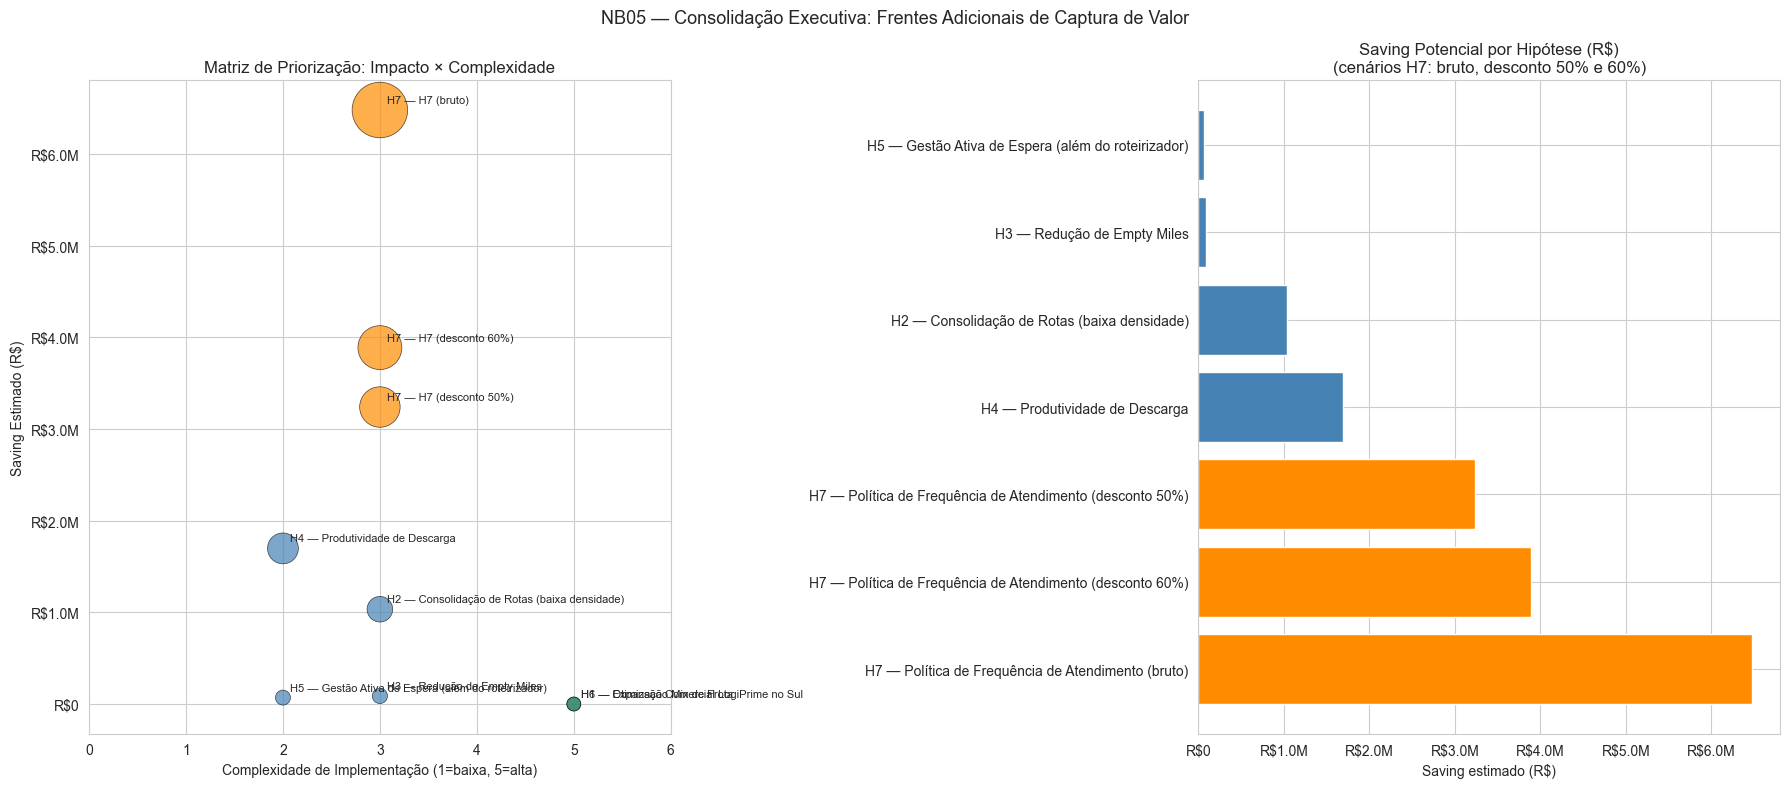

In [64]:
# Gráfico 8.1 — Matriz de Priorização: Impacto × Complexidade (atualizado para mostrar todos os savings H7)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

saving_norm = resumo_h5_df['Saving Estimado (R$)'].replace(0, 1)  # evita bolha invisível

# Gráfico de dispersão (inclui todos os cenários de H7)
axes[0].scatter(
    resumo_h5_df['Complexidade'],
    resumo_h5_df['Saving Estimado (R$)'],
    s=saving_norm / saving_norm.max() * 1500 + 100,
    alpha=0.7,
    color=['steelblue' if t == 'Redução de Custo' else
           'seagreen' if t == 'Expansão de Receita' else 'darkorange'
           for t in resumo_h5_df['Tipo']],
    edgecolors='black', linewidth=0.5
)
for _, row in resumo_h5_df.iterrows():
    axes[0].annotate(
        row['Hipótese'].replace('Política de Frequência de Atendimento', 'H7'),  # deixa mais curto
        (row['Complexidade'], row['Saving Estimado (R$)']),
        xytext=(5, 5), textcoords='offset points', fontsize=8
    )
axes[0].set_xlabel('Complexidade de Implementação (1=baixa, 5=alta)')
axes[0].set_ylabel('Saving Estimado (R$)')
axes[0].set_title('Matriz de Priorização: Impacto × Complexidade')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M' if x >= 1e6 else f'R${x:,.0f}'))
axes[0].set_xlim(0, 6)

# Gráfico 8.2 — Barras horizontais com todos os savings (inclui todos os cenários de H7)
df_saving = resumo_h5_df[resumo_h5_df['Saving Estimado (R$)'] > 0].sort_values('Saving Estimado (R$)')
cores_tipo = {
    'Redução de Custo': 'steelblue',
    'Redução de Custo + Capacidade': 'darkorange',
    'Expansão de Receita': 'seagreen'
}
axes[1].barh(
    df_saving['Hipótese'],
    df_saving['Saving Estimado (R$)'],
    color=[cores_tipo.get(t, 'steelblue') for t in df_saving['Tipo']],
    edgecolor='white'
)
axes[1].set_title('Saving Potencial por Hipótese (R$)\n(cenários H7: bruto, desconto 50% e 60%)')
axes[1].set_xlabel('Saving estimado (R$)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M' if x >= 1e6 else f'R${x:,.0f}'))
axes[1].invert_yaxis()

plt.suptitle('NB05 — Consolidação Executiva: Frentes Adicionais de Captura de Valor', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / '14_consolidacao_executiva_nb05.png', dpi=150, bbox_inches='tight')
plt.show()

- O Gráfico 8.1 (matriz de priorização) demos o posicionamento de H7 como o mais promisso, mesmo em cenários diversos (Desconto de 50-60%), trazendo alto saving. H4 aparece como segundo melhor saving (~R$ 1,7M), o que reforça a mensagem de "ganho acessível sem investimento". H1 e H6 aparecem sobrepostas no canto inferior direito pois demostram um saving zero ou indefinido.

In [65]:
# 8.2 — Exportação de Resultados para Excel (vários cenários de saving)
with pd.ExcelWriter(RESULTS_DIR / '05_Outras_Frentes_Resultados.xlsx',
                    engine='openpyxl') as writer:
    resumo_h5_df.to_excel(writer, sheet_name='Resumo Executivo', index=False)
    candidatas_consolidacao.to_excel(writer, sheet_name='H2 Rotas Candidatas', index=False)
    pdv_espera.to_excel(writer, sheet_name='H5 PDVs Espera', index=False)
    candidatos_consolidacao_pdv.to_excel(writer, sheet_name='H7 PDVs Freq', index=False)
    resumo_folga.to_excel(writer, sheet_name='H6 Folga Operacional', index=False)

    # Exporta cenários de saving H3 (empty miles)
    df_h3_scenarios = pd.DataFrame({
        'Cenário': ['Conservador (10%)', 'Base (20%)', 'Otimista (35%)'],
        'Saving H3 (R$)': savings_h3
    })
    df_h3_scenarios.to_excel(writer, sheet_name='H3 Cenários Empty Miles', index=False)

    # Exporta cenários de saving H7 (bruto, desconto 50%, desconto 60%)
    df_h7_scenarios = pd.DataFrame({
        'Cenário': [
            'H7 Bruto',
            'H7 Desconto 50%',
            'H7 Desconto 60%'
        ],
        'Saving H7 (R$)': [saving_h7_bruto, saving_h7_50, saving_h7_60]
    })
    df_h7_scenarios.to_excel(writer, sheet_name='H7 Cenários Freq', index=False)

print(f"Resultados exportados para: {RESULTS_DIR}")

# Exibe savings totais para cada cenário de H7
print("\nSaving total estimado (H1+H2+H3+H4+H5+H7):")
for label, val in zip(
    ['H7 Bruto', 'H7 Desconto 50%', 'H7 Desconto 60%'],
    [saving_h7_bruto, saving_h7_50, saving_h7_60]
):
    total = resumo_h5_df.loc[
        ~resumo_h5_df['Hipótese'].str.contains('H7'), 'Saving Estimado (R$)'
    ].sum() + val
    print(f"  {label}: R$ {total:,.0f}")

Resultados exportados para: D:\UERJ\Programacao_e_Codigos\PRG00_Case M&A em Logistica\results\05_outras_frentes

Saving total estimado (H1+H2+H3+H4+H5+H7):
  H7 Bruto: R$ 9,368,047
  H7 Desconto 50%: R$ 6,128,673
  H7 Desconto 60%: R$ 6,776,548


---

### Notas Metodológicas Finais

**Nota 1 — Independência com NB03/NB04:** As hipóteses H4 e H5 geram saving em horas de jornada de forma incremental. O NB03 capturou 35% de redução de espera via roteirizador. A descarga (H4) e o excesso estrutural de espera além dos 35% (H5) são parcelas adicionais não capturadas nos notebooks anteriores e não há dupla contagem.

**Nota 2 — Premissas Paramétricas:** Os custos fixos por tipo de veículo (H1) e as taxas de consolidação (H2, H7) são premissas que devem ser validadas operacionalmente. O notebook as declara explicitamente como constantes nomeadas para facilitar atualização.

**Nota 3 — Hierarquia de Certeza Analítica:** H3 (empty miles) e H5 (espera estrutural) têm a maior robustez analítica pois se baseiam diretamente em métricas presentes na base. H1 (custo fixo de frota) e H6 (receita incremental) têm maior incerteza por dependerem de dados externos ao case.

**Nota 4 — H6 (Expansão Comercial):** Esta hipótese não tem saving quantificado em R$ pois representa receita incremental futura, não redução de custo presente. A análise de folga operacional e maturidade de PDVs fornece o substrato qualitativo para uma tese de expansão comercial a ser desenvolvida com dados de receita.